In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0828_10_51_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0828_10_51_ppo_train.csv"
file_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\0109_18_09_ppo_train.csv"
data = pd.read_csv(file_path)

# --- 시각화 설정 ---
window_size = 10
ema_span = 10

# --- 계산 ---
rolling_mean = data.rolling(window=window_size, min_periods=1).mean()
rolling_std = data.rolling(window=window_size, min_periods=1).std()
ema = data.ewm(span=ema_span, min_periods=1).mean()

# --- 공통 스타일 ---
plt.style.use('seaborn-v0_8-whitegrid')

# -------------------------------
# real_makespan
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거 -> 이 라인을 주석 처리
# ax.plot(data['episode'], data['real_makespan'],
#         label="Original Data",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['real_makespan'] - rolling_std['real_makespan'],
                rolling_mean['real_makespan'] + rolling_std['real_makespan'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

ax.plot(ema['episode'], ema['real_makespan'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

z = np.polyfit(data['episode'], data['real_makespan'], 1)
p = np.poly1d(z)
ax.plot(data['episode'], p(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

y_min = data['real_makespan'].min()
y_max = data['real_makespan'].max()
ax.set_ylim(y_min * 0.98, y_max * 1.02)

ax.set_title("Makespan", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Real Makespan", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
plt.savefig("real_makespan_trend.png", dpi=400, bbox_inches='tight')
plt.show()

# -------------------------------
# actor_loss
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거
# ax.plot(data['episode'], data['actor_loss'],
#         label="actor_loss (Original)",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.plot(rolling_mean['episode'], rolling_mean['actor_loss'],
        label=f"actor_loss (MA {window_size})",
        color='royalblue', linewidth=2.5)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['actor_loss'] - rolling_std['actor_loss'],
                rolling_mean['actor_loss'] + rolling_std['actor_loss'],
                color='royalblue', alpha=0.15)

ax.set_title("Actor Loss Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Actor Loss", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
plt.savefig("actor_loss_trend.png", dpi=400, bbox_inches='tight')
plt.show()


# -------------------------------
# violations
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거
# ax.plot(data['episode'], data['violations'],
#         label="Original Data",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['violations'] - rolling_std['violations'],
                rolling_mean['violations'] + rolling_std['violations'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

ax.plot(ema['episode'], ema['violations'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

z_v = np.polyfit(data['episode'], data['violations'], 1)
p_v = np.poly1d(z_v)
ax.plot(data['episode'], p_v(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

y_min_v = data['violations'].min()
y_max_v = data['violations'].max()
ax.set_ylim(max(0, y_min_v - 1), y_max_v + 1)

ax.set_title("violations Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("violations", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
# plt.savefig("violations_trend.png", dpi=400, bbox_inches='tight')
plt.show()

DataError: Cannot aggregate non-numeric type: object

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_detail.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"

file1_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\1231_14_19_ppo_train.csv"
file2_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\1231_14_19_ppo_train.csv"

data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)
# episode,real_makespan,baseline_makespan,advantage,actor_loss,violations
# Window size 설정
window_size = 50

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# real_makespan
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data1['episode'], data1['real_makespan'], 
         label="real_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data1['episode'], 
         data1['real_makespan'].rolling(window=window_size).mean(), 
         label=f"real_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("real_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("real_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# actor_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['actor_loss'], 
         label="actor_loss (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['actor_loss'].rolling(window=window_size).mean(), 
         label=f"actor_loss (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("actor_loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("actor_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# advantage
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['advantage'], 
         label="advantage (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['advantage'].rolling(window=window_size).mean(), 
         label=f"advantage (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("advantage", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("advantage", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# -------------------------------
# entropy_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['entropy_loss'], 
         label="entropy_loss (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['entropy_loss'].rolling(window=window_size).mean(), 
         label=f"entropy_loss (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("entropy_loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("entropy_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# -------------------------------
# violations
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['violations'], 
         label="violations (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['violations'].rolling(window=window_size).mean(), 
         label=f"violations (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("violations", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\d\\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\\PPO\\result\\log\\ppo\\1231_14_19_ppo_train.csv'

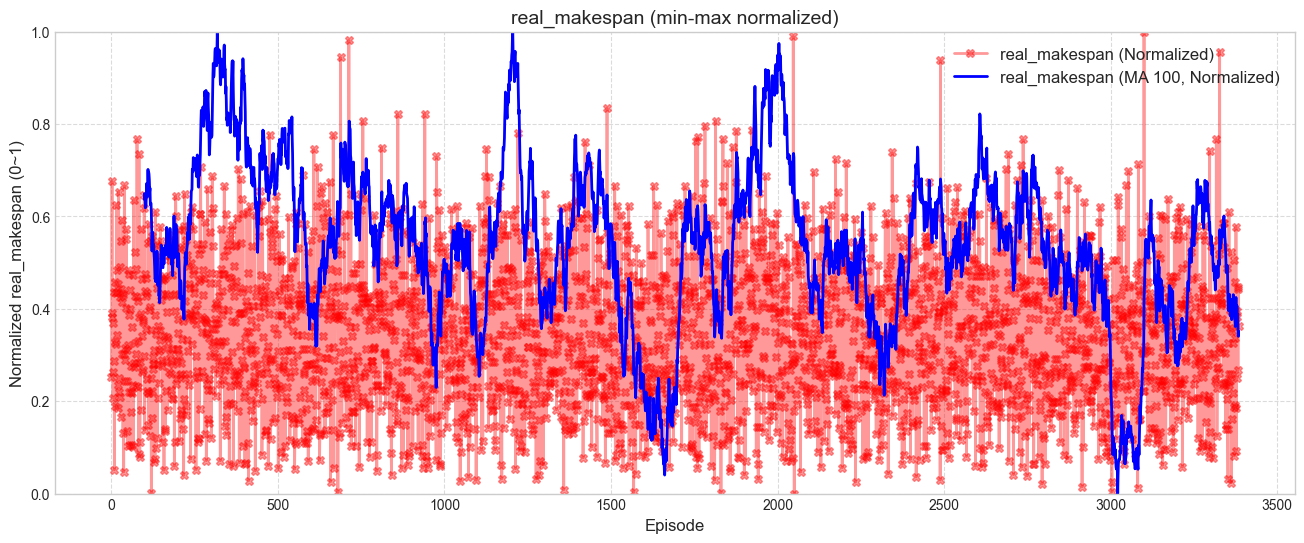

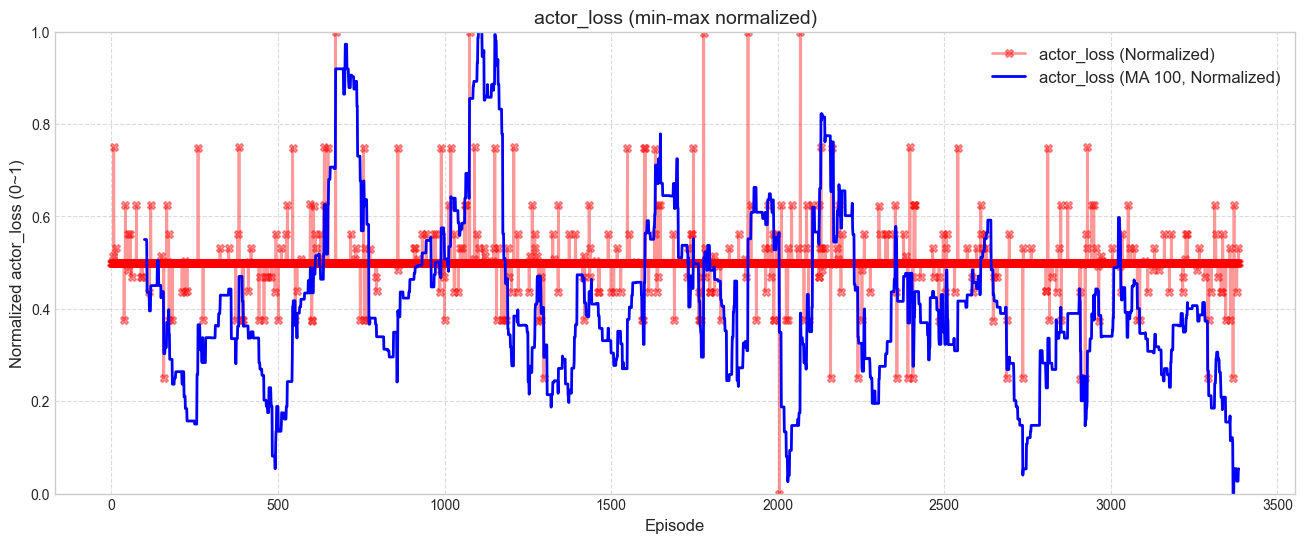

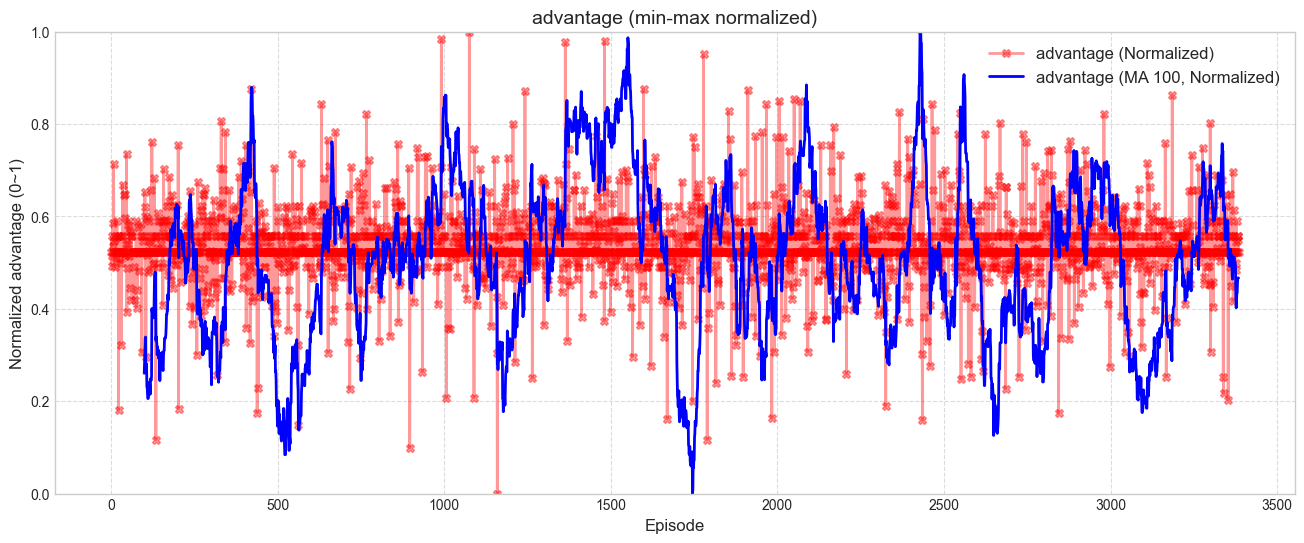

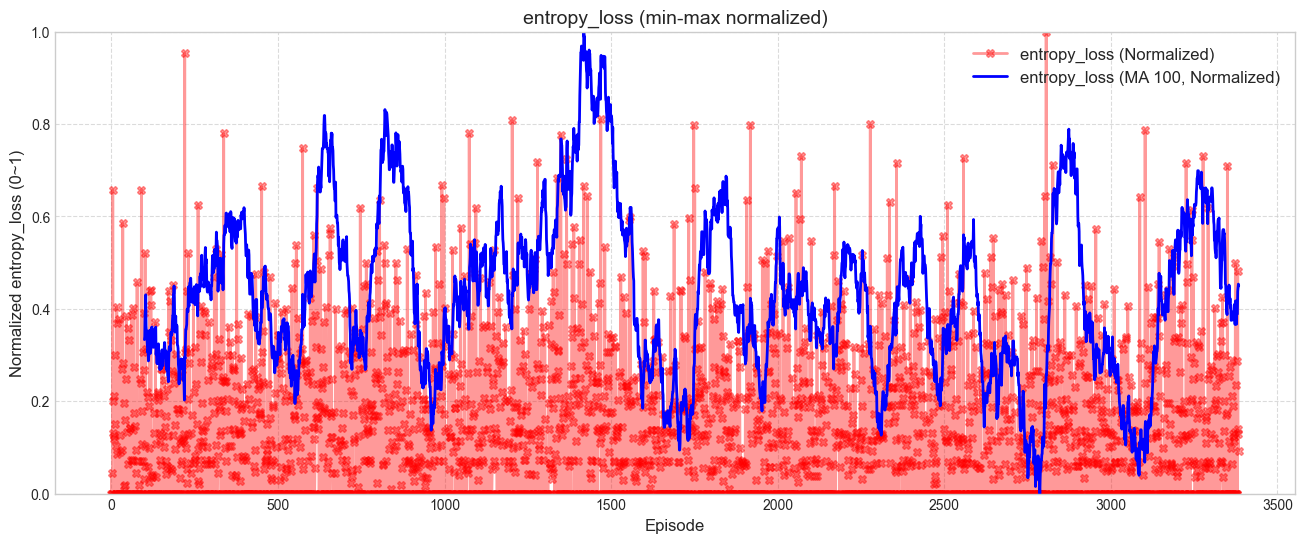

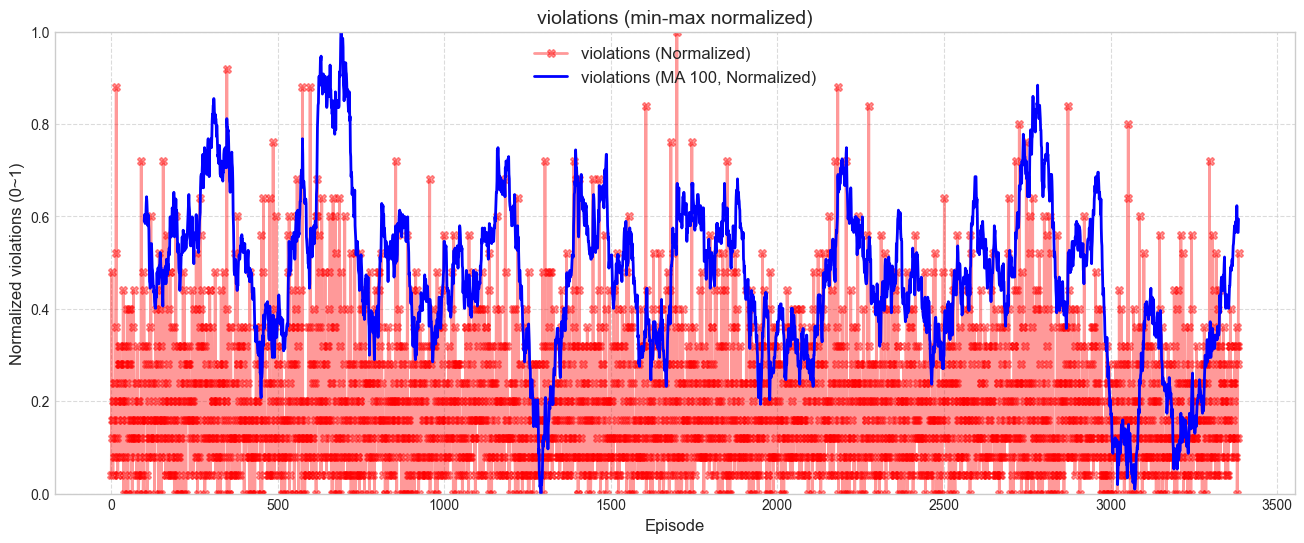

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_detail.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1021_18_04_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1021_18_04_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1113_16_37_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1113_16_37_ppo_train.csv"

file1_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\0108_10_52_ppo_train.csv"
file2_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\0108_10_52_ppo_train.csv"

data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)

# episode,real_makespan,baseline_makespan,advantage,actor_loss,violations
# Window size 설정
window_size = 100

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# min-max 정규화 함수
# -------------------------------
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val):
        return series * 0  # 전부 NaN이면 그냥 0으로
    if max_val == min_val:
        # 값이 전부 같을 때 0으로 두거나 0.5로 둘 수 있음 (여기선 0으로)
        return series * 0
    return (series - min_val) / (max_val - min_val)

# ===============================
# real_makespan (정규화)
# ===============================
real_raw = data1['real_makespan']
real_smoothed = real_raw.rolling(window=window_size).mean()

real_norm = min_max_scale(real_raw)
real_smoothed_norm = min_max_scale(real_smoothed.dropna())

plt.figure(figsize=(16, 6))
plt.plot(
    data1['episode'],
    real_norm,
    label="real_makespan (Normalized)",
    marker='X',
    markersize=marker_size,
    linewidth=line_width,
    color='red',
    alpha=0.4
)

# rolling 때문에 앞부분 NaN → 인덱스 맞춰서 그림
plt.plot(
    data1['episode'][window_size-1:],
    real_smoothed_norm,
    label=f"real_makespan (MA {window_size}, Normalized)",
    color='blue',
    linewidth=line_width
)

plt.title("real_makespan (min-max normalized)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Normalized real_makespan (0~1)", fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ===============================
# actor_loss (정규화)
# ===============================
actor_raw = data2['actor_loss']
actor_smoothed = actor_raw.rolling(window=window_size).mean()

actor_norm = min_max_scale(actor_raw)
actor_smoothed_norm = min_max_scale(actor_smoothed.dropna())

plt.figure(figsize=(16, 6))
plt.plot(
    data2['episode'],
    actor_norm,
    label="actor_loss (Normalized)",
    marker='X',
    markersize=marker_size,
    linewidth=line_width,
    color='red',
    alpha=0.4
)

plt.plot(
    data2['episode'][window_size-1:],
    actor_smoothed_norm,
    label=f"actor_loss (MA {window_size}, Normalized)",
    color='blue',
    linewidth=line_width
)

plt.title("actor_loss (min-max normalized)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Normalized actor_loss (0~1)", fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ===============================
# advantage (정규화)
# ===============================
adv_raw = data2['advantage']
adv_smoothed = adv_raw.rolling(window=window_size).mean()

adv_norm = min_max_scale(adv_raw)
adv_smoothed_norm = min_max_scale(adv_smoothed.dropna())

plt.figure(figsize=(16, 6))
plt.plot(
    data2['episode'],
    adv_norm,
    label="advantage (Normalized)",
    marker='X',
    markersize=marker_size,
    linewidth=line_width,
    color='red',
    alpha=0.4
)

plt.plot(
    data2['episode'][window_size-1:],
    adv_smoothed_norm,
    label=f"advantage (MA {window_size}, Normalized)",
    color='blue',
    linewidth=line_width
)

plt.title("advantage (min-max normalized)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Normalized advantage (0~1)", fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ===============================
# entropy_loss (정규화)
# ===============================
entropy_raw = data2['entropy_loss']
entropy_smoothed = entropy_raw.rolling(window=window_size).mean()

entropy_norm = min_max_scale(entropy_raw)
entropy_smoothed_norm = min_max_scale(entropy_smoothed.dropna())

plt.figure(figsize=(16, 6))
plt.plot(
    data2['episode'],
    entropy_norm,
    label="entropy_loss (Normalized)",
    marker='X',
    markersize=marker_size,
    linewidth=line_width,
    color='red',
    alpha=0.4
)

plt.plot(
    data2['episode'][window_size-1:],
    entropy_smoothed_norm,
    label=f"entropy_loss (MA {window_size}, Normalized)",
    color='blue',
    linewidth=line_width
)

plt.title("entropy_loss (min-max normalized)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Normalized entropy_loss (0~1)", fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ===============================
# violations (정규화)
# ===============================
viol_raw = data2['violations']
viol_smoothed = viol_raw.rolling(window=window_size).mean()

viol_norm = min_max_scale(viol_raw)
viol_smoothed_norm = min_max_scale(viol_smoothed.dropna())

plt.figure(figsize=(16, 6))
plt.plot(
    data2['episode'],
    viol_norm,
    label="violations (Normalized)",
    marker='X',
    markersize=marker_size,
    linewidth=line_width,
    color='red',
    alpha=0.4
)

plt.plot(
    data2['episode'][window_size-1:],
    viol_smoothed_norm,
    label=f"violations (MA {window_size}, Normalized)",
    color='blue',
    linewidth=line_width
)

plt.title("violations (min-max normalized)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Normalized violations (0~1)", fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


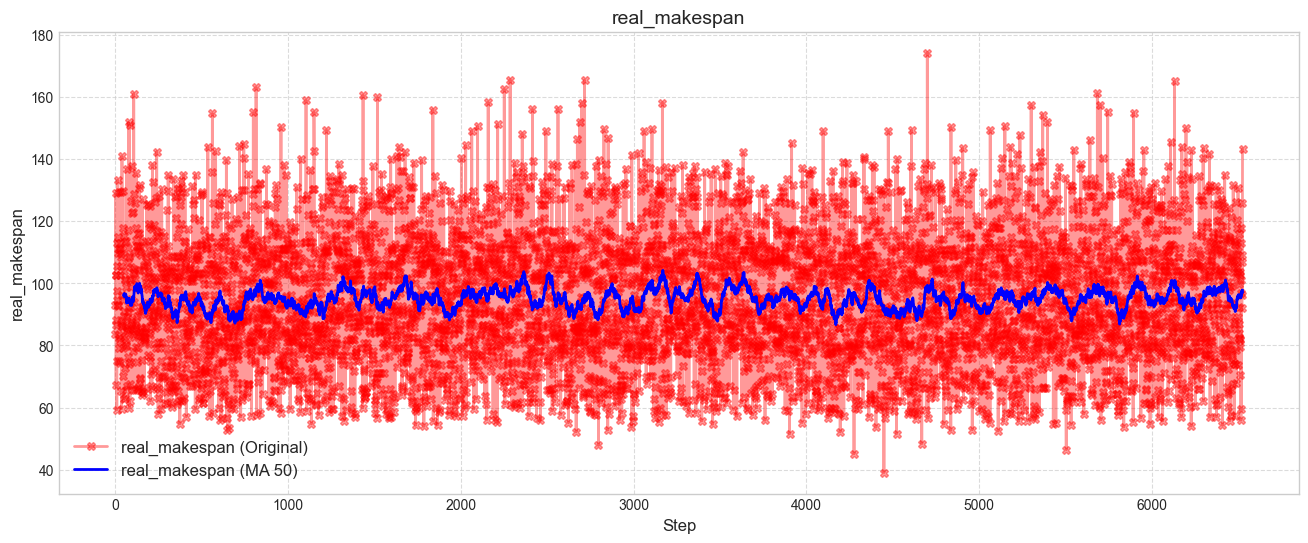

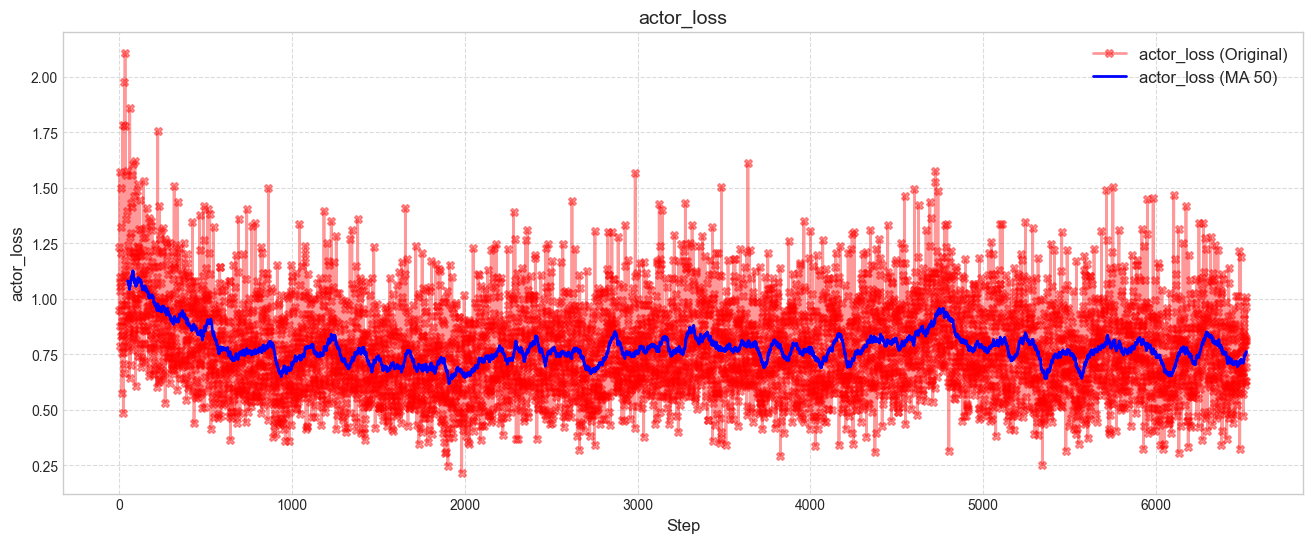

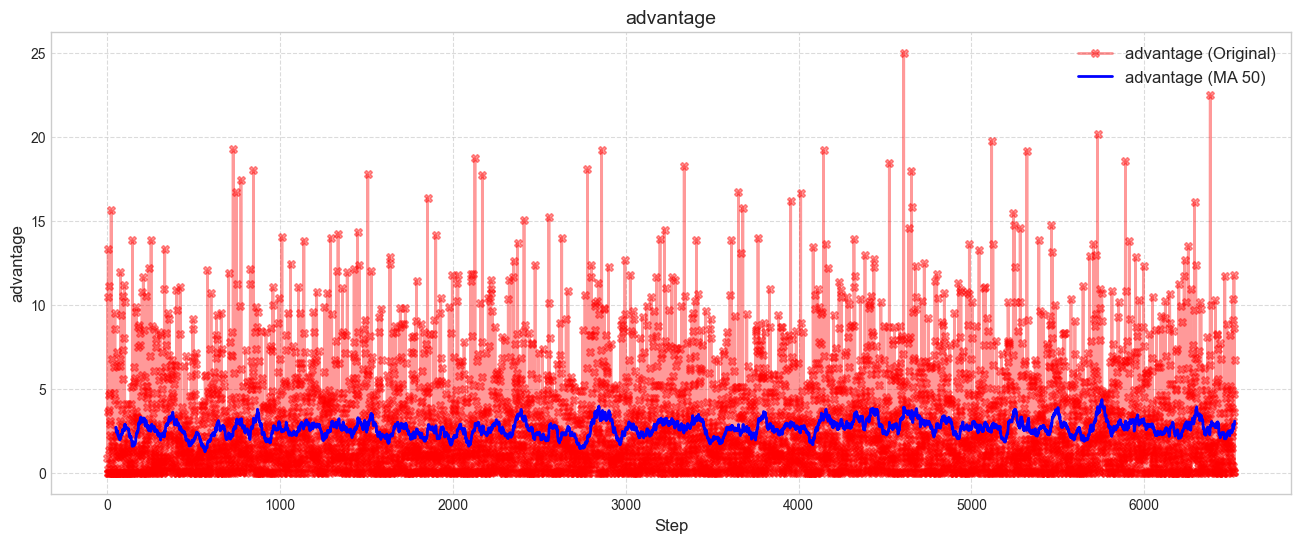

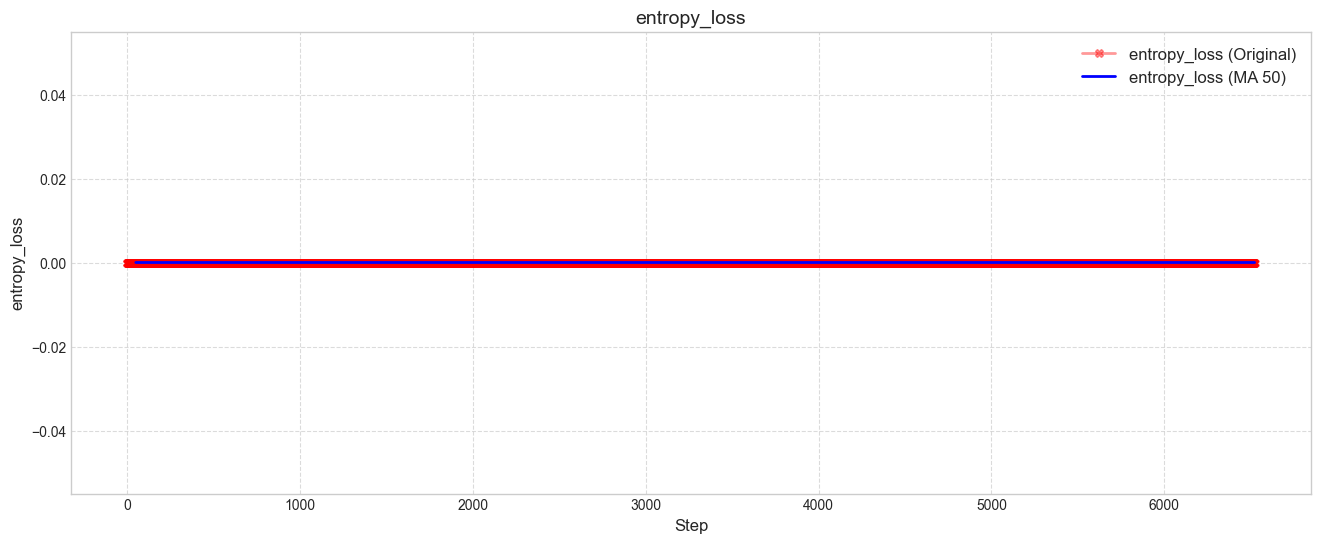

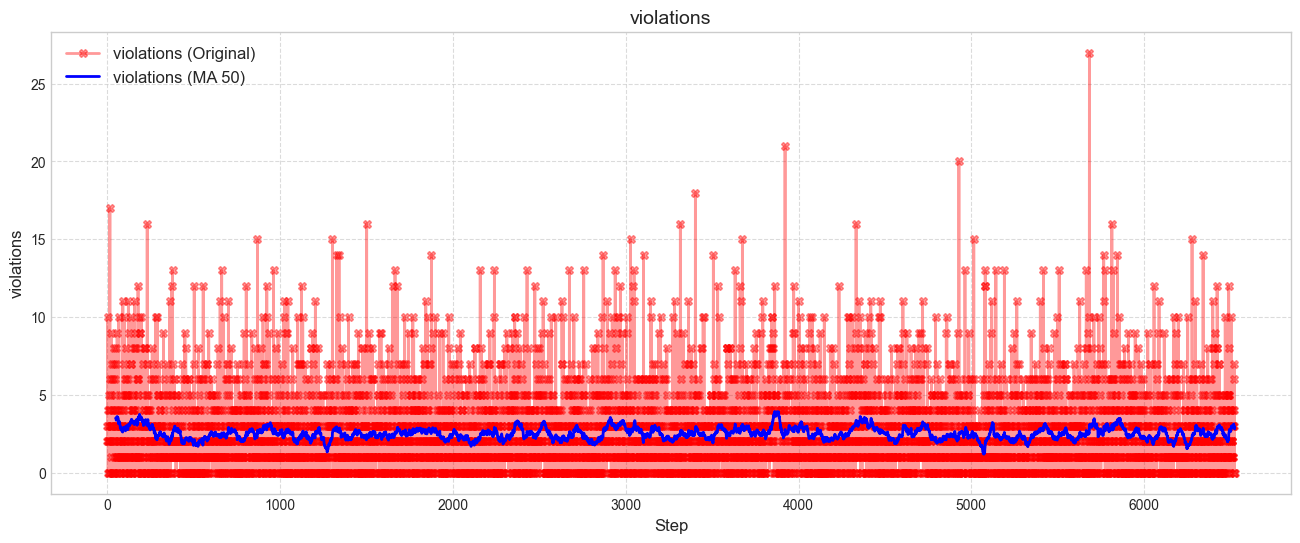

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_detail.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0827_18_12_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1021_18_04_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1021_18_04_ppo_train.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1113_16_37_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\9month\PPO\result\log\ppo\1113_16_37_ppo_train.csv"

file1_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\0109_18_09_ppo_train.csv"
file2_path = r"C:\Users\User\Desktop\d\지금휴리스틱과RL에서조립착수일먼저하는거제거한상태베스트인데\PPO\result\log\ppo\0109_18_09_ppo_train.csv"

data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)
# episode,real_makespan,baseline_makespan,advantage,actor_loss,violations
# Window size 설정
window_size = 50

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# real_makespan
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data1['episode'], data1['real_makespan'], 
         label="real_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data1['episode'], 
         data1['real_makespan'].rolling(window=window_size).mean(), 
         label=f"real_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("real_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("real_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# actor_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['actor_loss'], 
         label="actor_loss (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['actor_loss'].rolling(window=window_size).mean(), 
         label=f"actor_loss (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("actor_loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("actor_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# advantage
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['advantage'], 
         label="advantage (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['advantage'].rolling(window=window_size).mean(), 
         label=f"advantage (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("advantage", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("advantage", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# -------------------------------
# entropy_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['entropy_loss'], 
         label="entropy_loss (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['entropy_loss'].rolling(window=window_size).mean(), 
         label=f"entropy_loss (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("entropy_loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("entropy_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# -------------------------------
# violations
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['violations'], 
         label="violations (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['violations'].rolling(window=window_size).mean(), 
         label=f"violations (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("violations", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
file_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"
data = pd.read_csv(file_path)

# --- 시각화 설정 ---
window_size = 100
ema_span = 100

# --- 계산 ---
rolling_mean = data.rolling(window=window_size, min_periods=1).mean()
rolling_std = data.rolling(window=window_size, min_periods=1).std()
ema = data.ewm(span=ema_span, min_periods=1).mean()

# --- 공통 스타일 ---
plt.style.use('seaborn-v0_8-whitegrid')

# -------------------------------
# real_makespan
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거 -> 이 라인을 주석 처리
# ax.plot(data['episode'], data['real_makespan'],
#         label="Original Data",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['real_makespan'] - rolling_std['real_makespan'],
                rolling_mean['real_makespan'] + rolling_std['real_makespan'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

ax.plot(ema['episode'], ema['real_makespan'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

z = np.polyfit(data['episode'], data['real_makespan'], 1)
p = np.poly1d(z)
ax.plot(data['episode'], p(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

y_min = data['real_makespan'].min()
y_max = data['real_makespan'].max()
ax.set_ylim(y_min * 0.98, y_max * 1.02)

ax.set_title("Real Makespan Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Real Makespan", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
plt.savefig("real_makespan_trend.png", dpi=400, bbox_inches='tight')
plt.show()

# -------------------------------
# actor_loss
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거
# ax.plot(data['episode'], data['actor_loss'],
#         label="actor_loss (Original)",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.plot(rolling_mean['episode'], rolling_mean['actor_loss'],
        label=f"actor_loss (MA {window_size})",
        color='royalblue', linewidth=2.5)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['actor_loss'] - rolling_std['actor_loss'],
                rolling_mean['actor_loss'] + rolling_std['actor_loss'],
                color='royalblue', alpha=0.15)

ax.set_title("Actor Loss Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Actor Loss", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
plt.savefig("actor_loss_trend.png", dpi=400, bbox_inches='tight')
plt.show()

# -------------------------------
# violations
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# # 1. 붉은 점(원본 데이터) 제거
# ax.plot(data['episode'], data['violations'],
#         label="Original Data",
#         marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['violations'] - rolling_std['violations'],
                rolling_mean['violations'] + rolling_std['violations'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

ax.plot(ema['episode'], ema['violations'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

z_v = np.polyfit(data['episode'], data['violations'], 1)
p_v = np.poly1d(z_v)
ax.plot(data['episode'], p_v(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

y_min_v = data['violations'].min()
y_max_v = data['violations'].max()
ax.set_ylim(max(0, y_min_v - 1), y_max_v + 1)

ax.set_title("Violations Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Violations", fontsize=12)
ax.legend(fontsize=11)

# 2. 고해상도(DPI 400) 파일로 저장
plt.savefig("violations_trend.png", dpi=400, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Research\\과제\\Contech\\give_2\\PPO\\result\\log\\ppo\\0825_15_45_ppo_train.csv'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 파일 경로
file_path = r"C:\Users\User\Desktop\d\9month - selflabeling후_makespan계산이상\PPO\result\log\ppo\0105_01_43_ppo_train.csv.csv"
data = pd.read_csv(file_path)

# --- 시각화 설정 ---
window_size = 50
ema_span = 100  # EMA를 위한 Span 값, 클수록 부드러워집니다.

# --- 계산 ---
rolling_mean = data.rolling(window=window_size, min_periods=1).mean()
rolling_std = data.rolling(window=window_size, min_periods=1).std()
# EMA 계산 추가
ema = data.ewm(span=ema_span, min_periods=1).mean()

# --- 공통 스타일 ---
plt.style.use('seaborn-v0_8-whitegrid')

# -------------------------------
# real_makespan (✨ 수정됨)
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

# 원본 데이터 (기존과 동일)
ax.plot(data['episode'], data['real_makespan'],
        label="Original Data",
        marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

# 신뢰 구간 (기존과 동일)
ax.fill_between(rolling_mean['episode'],
                rolling_mean['real_makespan'] - rolling_std['real_makespan'],
                rolling_mean['real_makespan'] + rolling_std['real_makespan'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

# 1. 추세선을 SMA에서 EMA로 변경하여 더 부드럽게
ax.plot(ema['episode'], ema['real_makespan'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

# 2. 전체적인 추세를 보여주기 위한 선형 회귀선 추가
z = np.polyfit(data['episode'], data['real_makespan'], 1)
p = np.poly1d(z)
ax.plot(data['episode'], p(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

# 3. Y축 범위를 데이터에 맞게 조절하여 변화를 강조
y_min = data['real_makespan'].min()
y_max = data['real_makespan'].max()
ax.set_ylim(y_min * 0.98, y_max * 1.02)

ax.set_title("Real Makespan Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Real Makespan", fontsize=12)
ax.legend(fontsize=11)
plt.show()

# -------------------------------
# actor_loss (👍 완벽하므로 수정 없음)
# -------------------------------
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(data['episode'], data['actor_loss'],
        label="actor_loss (Original)",
        marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

ax.plot(rolling_mean['episode'], rolling_mean['actor_loss'],
        label=f"actor_loss (MA {window_size})",
        color='royalblue', linewidth=2.5)

ax.fill_between(rolling_mean['episode'],
                rolling_mean['actor_loss'] - rolling_std['actor_loss'],
                rolling_mean['actor_loss'] + rolling_std['actor_loss'],
                color='royalblue', alpha=0.15)

ax.set_title("Actor Loss Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Actor Loss", fontsize=12)
ax.legend(fontsize=11)
plt.show()

# -------------------------------
# violations (✨ 수정됨)
# -------------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# 원본 데이터
ax.plot(data['episode'], data['violations'],
        label="Original Data",
        marker='.', markersize=5, linestyle='None', color='indianred', alpha=0.4)

# 신뢰 구간
ax.fill_between(rolling_mean['episode'],
                rolling_mean['violations'] - rolling_std['violations'],
                rolling_mean['violations'] + rolling_std['violations'],
                color='royalblue', alpha=0.1, label='1-Std Dev Range')

# 1. 추세선을 EMA로 변경
ax.plot(ema['episode'], ema['violations'],
        label=f"Trend (EMA {ema_span})",
        color='royalblue', linewidth=2.5)

# 2. 선형 회귀선 추가
z_v = np.polyfit(data['episode'], data['violations'], 1)
p_v = np.poly1d(z_v)
ax.plot(data['episode'], p_v(data['episode']),
        label="Overall Linear Trend",
        color="darkorange", linestyle="--", linewidth=2)

# 3. Y축 범위 조절
y_min_v = data['violations'].min()
y_max_v = data['violations'].max()
ax.set_ylim(max(0, y_min_v - 1), y_max_v + 1) # 0 밑으로 내려가지 않게

ax.set_title("Violations Trend", fontsize=15, fontweight='bold')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Violations", fontsize=12)
ax.legend(fontsize=11)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\d\\9month - selflabeling후_makespan계산이상\\PPO\\result\\log\\ppo\\0105_01_43_ppo_train.csv.csv'

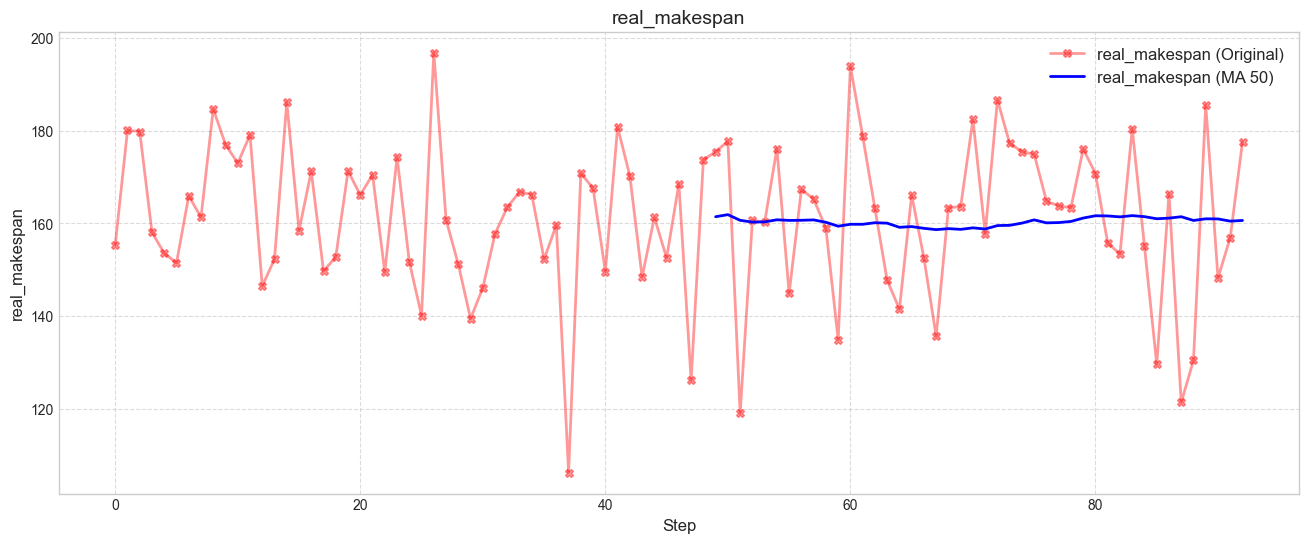

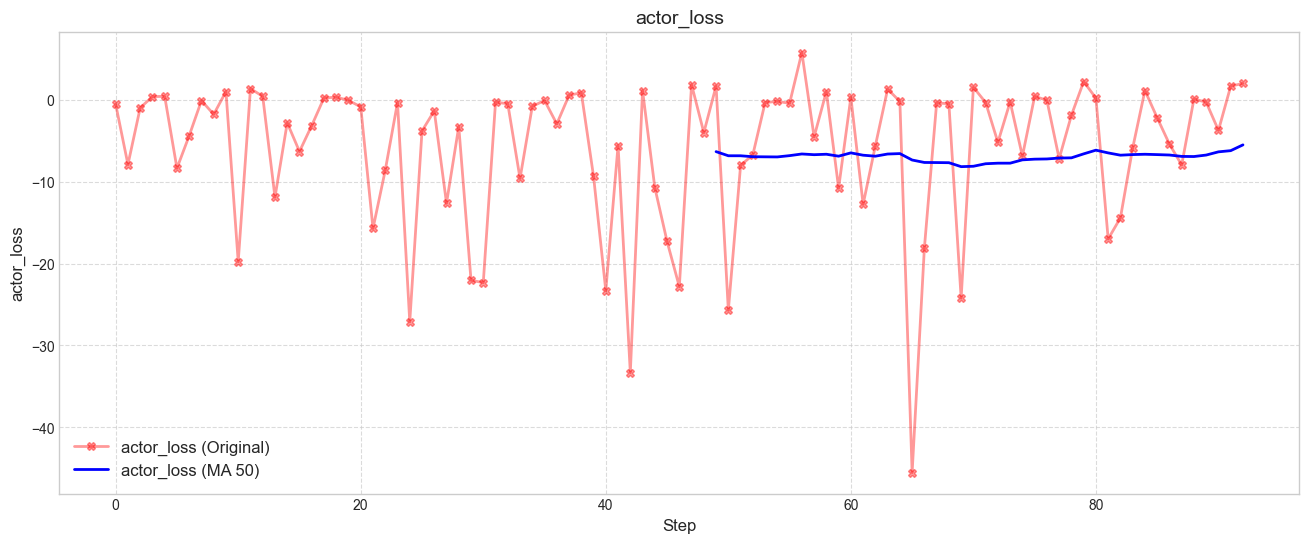

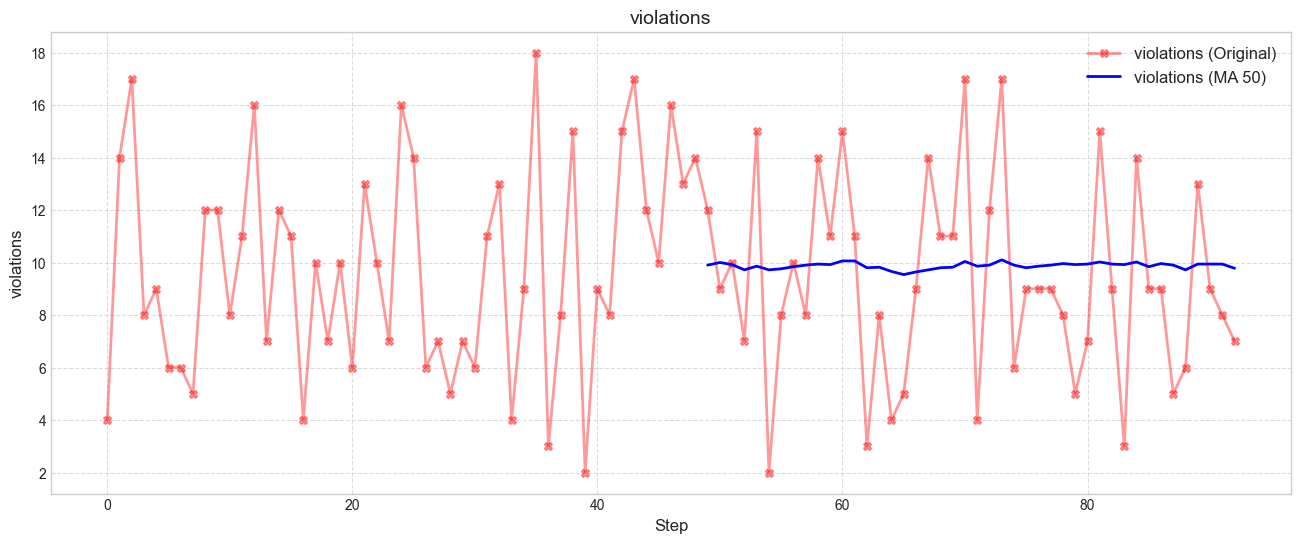

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0823_00_10_assembly_rl_detail.csv"

# file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"
# file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0825_15_45_ppo_train.csv"

file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0826_15_24_ppo_train.csv"
file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\PPO\result\log\ppo\0826_15_24_ppo_train.csv"
data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)
# episode,real_makespan,baseline_makespan,advantage,actor_loss,violations
# Window size 설정
window_size = 50

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# real_makespan
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data1['episode'], data1['real_makespan'], 
         label="real_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data1['episode'], 
         data1['real_makespan'].rolling(window=window_size).mean(), 
         label=f"real_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("real_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("real_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# actor_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['actor_loss'], 
         label="actor_loss (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['actor_loss'].rolling(window=window_size).mean(), 
         label=f"actor_loss (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("actor_loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("actor_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# violations
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['violations'], 
         label="violations (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['violations'].rolling(window=window_size).mean(), 
         label=f"violations (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("violations", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()





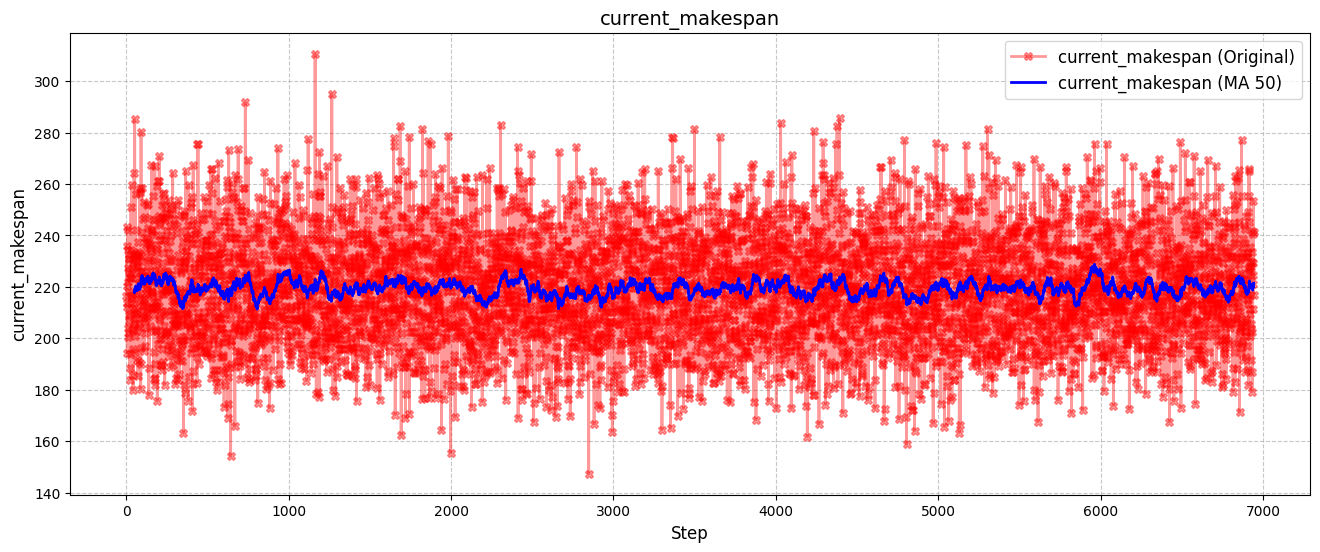

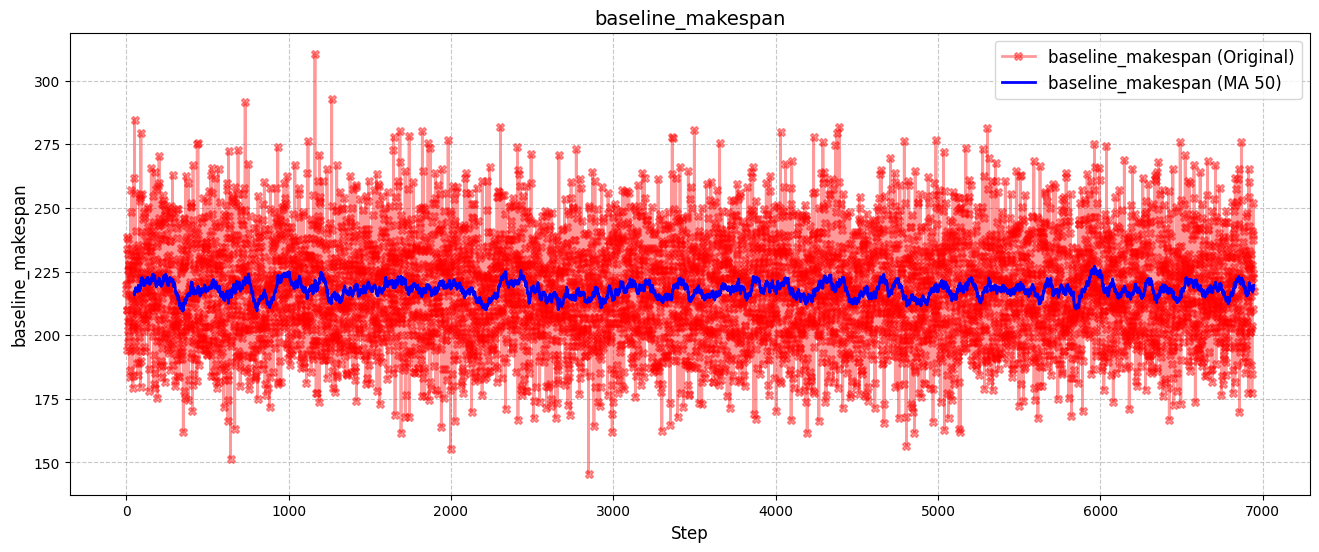

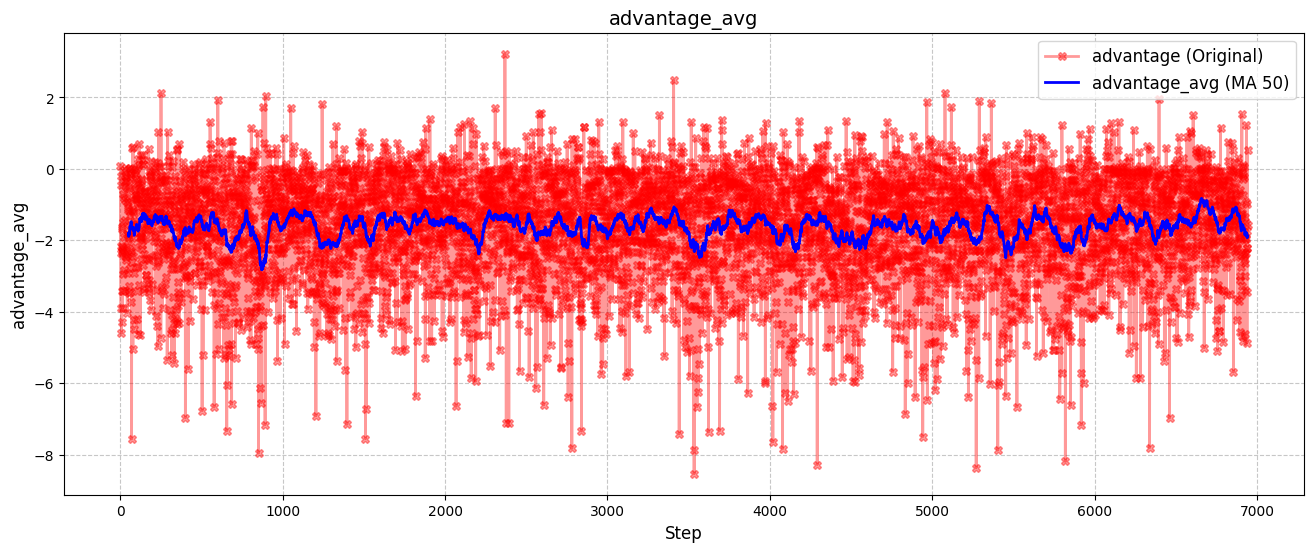

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0822_15_20_assembly_rl_train.csv"
file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0822_15_20_assembly_rl_detail.csv"
data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)

# Window size 설정
window_size = 50

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# current_makespan
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data1['episode'], data1['actor_makespan'], 
         label="current_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data1['episode'], 
         data1['actor_makespan'].rolling(window=window_size).mean(), 
         label=f"current_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("current_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("current_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# avg_actor_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['baseline_makespan'], 
         label="baseline_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['baseline_makespan'].rolling(window=window_size).mean(), 
         label=f"baseline_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("baseline_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("baseline_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# advantage_avg
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['advantage'], 
         label="advantage (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['advantage'].rolling(window=window_size).mean(), 
         label=f"advantage_avg (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("advantage_avg", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("advantage_avg", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


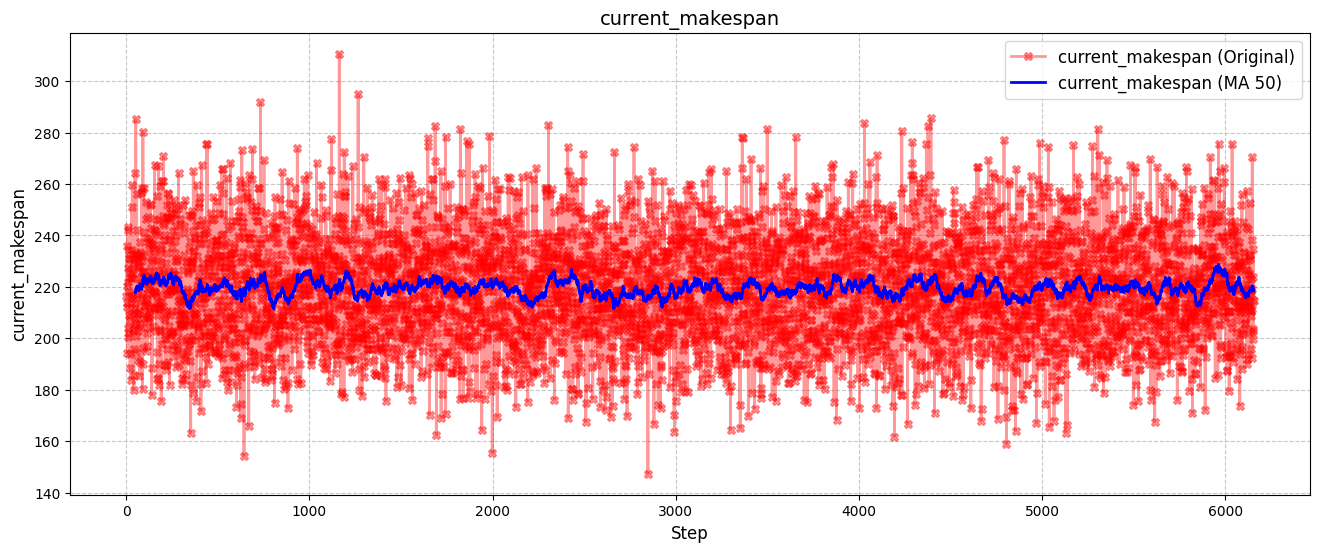

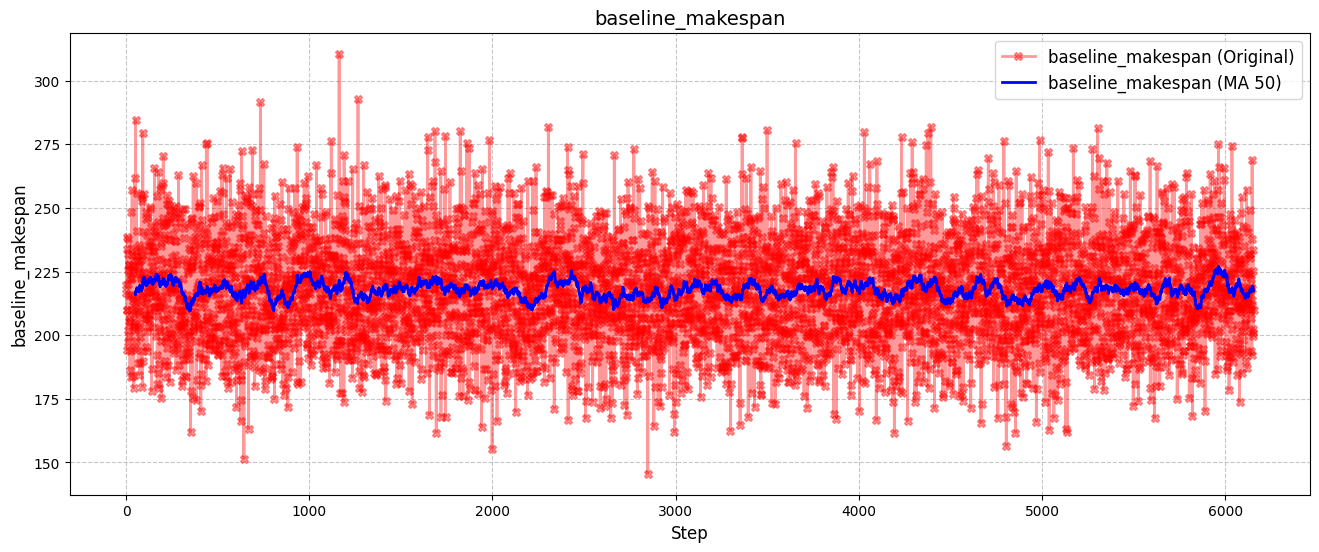

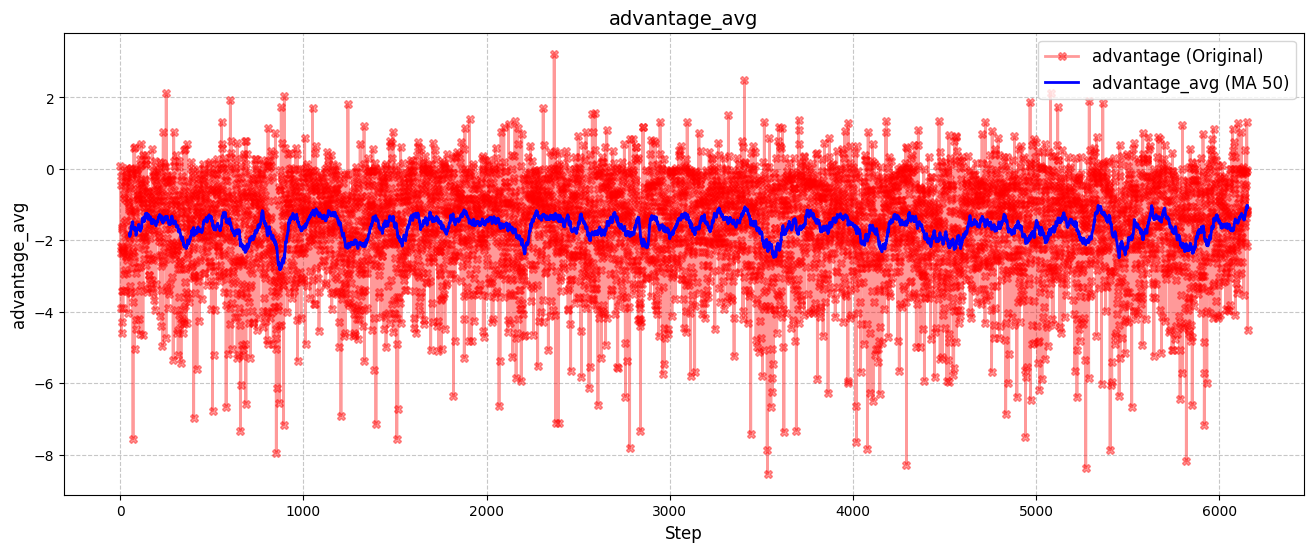

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file1_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0822_15_20_assembly_rl_train.csv"
file2_path = r"C:\Users\User\Desktop\Research\과제\Contech\give_2\result\log\assembly_rl\0822_15_20_assembly_rl_detail.csv"
data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)

# Window size 설정
window_size = 50

# 공통 스타일 설정
line_width = 2
marker_size = 6

# -------------------------------
# current_makespan
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data1['episode'], data1['actor_makespan'], 
         label="current_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data1['episode'], 
         data1['actor_makespan'].rolling(window=window_size).mean(), 
         label=f"current_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("current_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("current_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# avg_actor_loss
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['baseline_makespan'], 
         label="baseline_makespan (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['baseline_makespan'].rolling(window=window_size).mean(), 
         label=f"baseline_makespan (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("baseline_makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("baseline_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# advantage_avg
# -------------------------------
plt.figure(figsize=(16, 6))
plt.plot(data2['episode'], data2['advantage'], 
         label="advantage (Original)", 
         marker='X', markersize=marker_size, linewidth=line_width, color='red', alpha=0.4)
plt.plot(data2['episode'], 
         data2['advantage'].rolling(window=window_size).mean(), 
         label=f"advantage_avg (MA {window_size})", 
         color='blue', linewidth=line_width)
plt.title("advantage_avg", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("advantage_avg", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


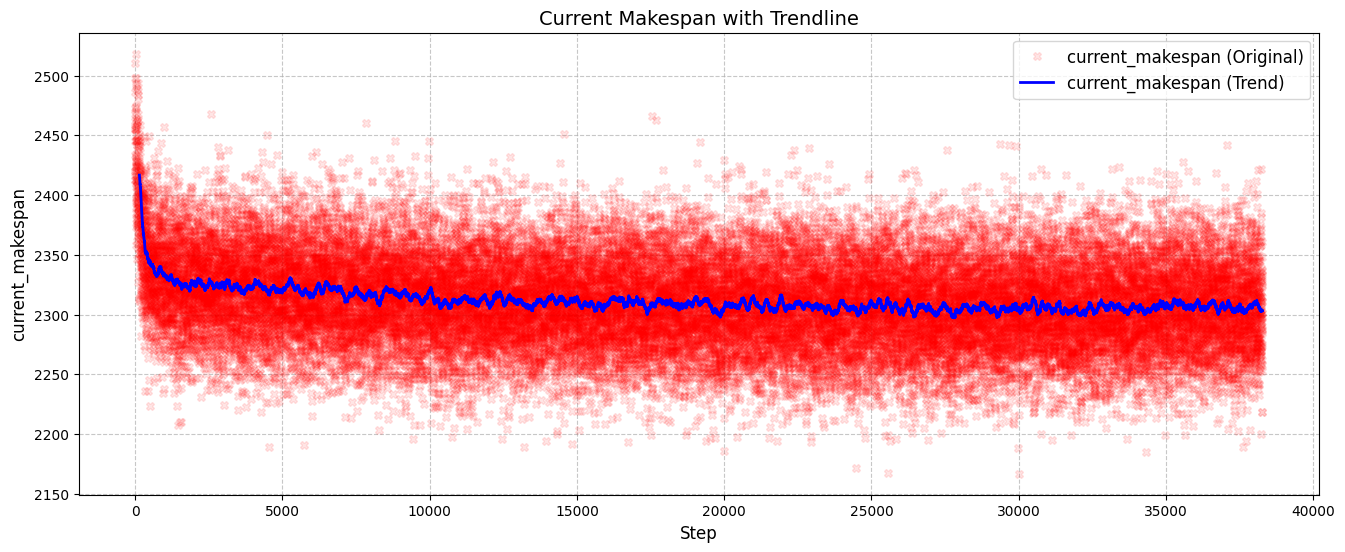

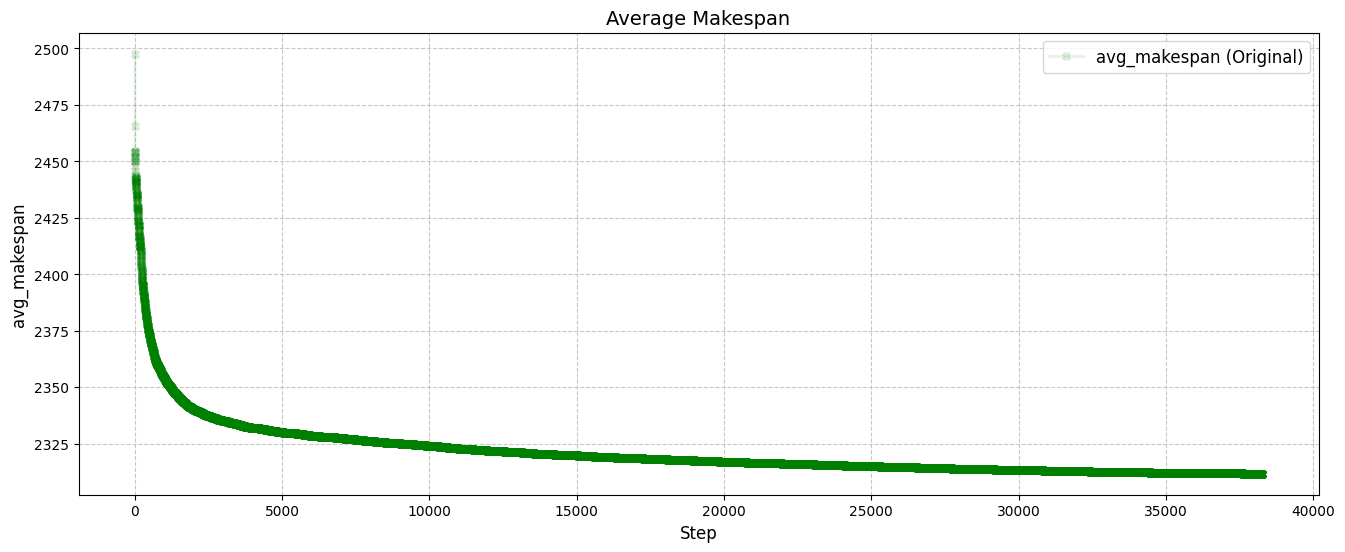

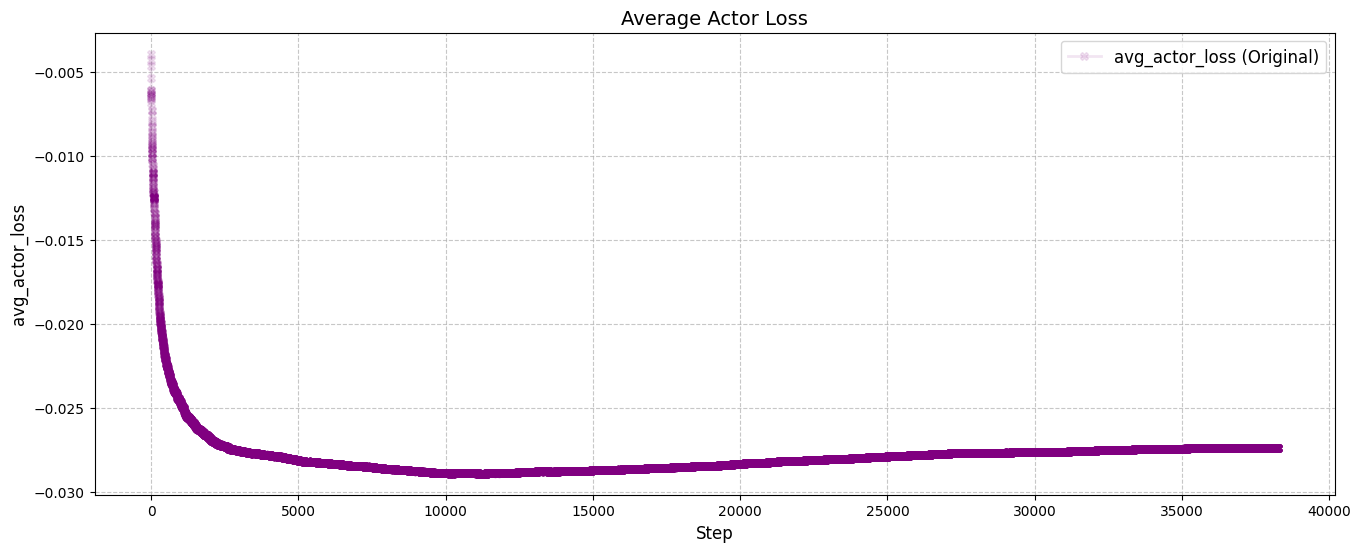

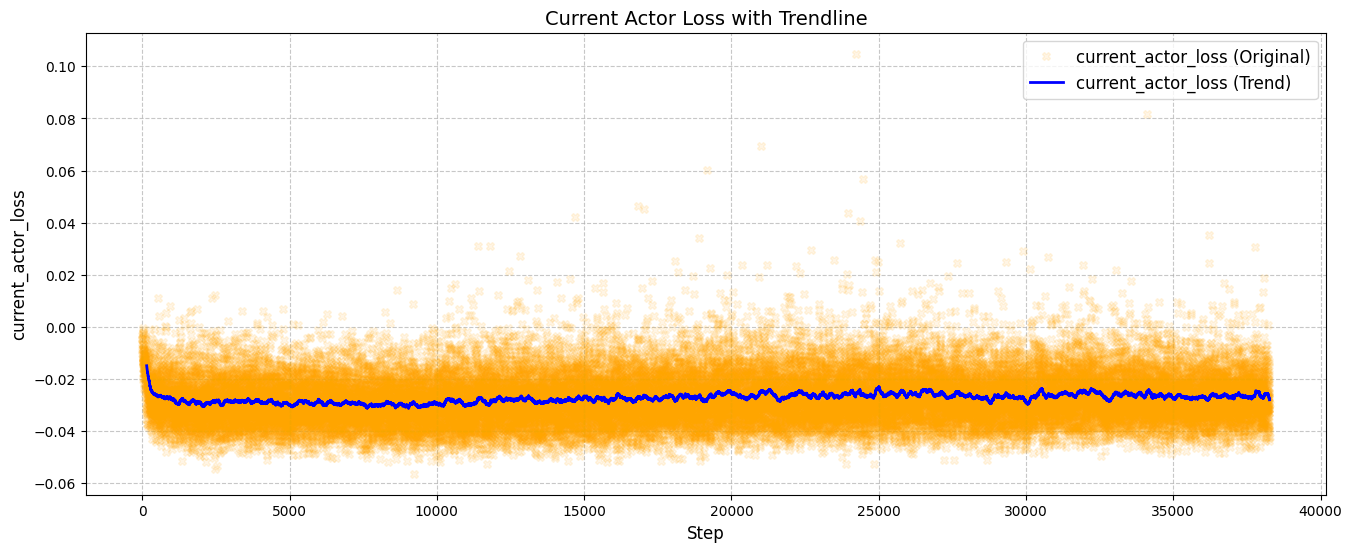

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file1_path = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\log\ppo_rollout\0115_19_10_train.csv"

# CSV 파일 읽기
data1 = pd.read_csv(file1_path)

# Window size 설정
window_size = 150

# Moving average 계산
data1['current_makespan_trend'] = data1['current_makespan'].rolling(window=window_size).mean()
data1['current_actor_loss_trend'] = data1['current_actor_loss'].rolling(window=window_size).mean()

# 공통 스타일 설정
line_width = 2
marker_size = 6
transparency = 0.1

# (step, current_makespan) 그래프
plt.figure(figsize=(16, 6))
plt.plot(data1['step'], data1['current_makespan'], label="current_makespan (Original)", marker='X', markersize=marker_size, linewidth=0, color='red', alpha=transparency)
plt.plot(data1['step'], data1['current_makespan_trend'], label="current_makespan (Trend)", color='blue', linewidth=line_width)
plt.title("Current Makespan with Trendline", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("current_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# (step, avg_makespan) 그래프
plt.figure(figsize=(16, 6))
plt.plot(data1['step'], data1['avg_makespan'], label="avg_makespan (Original)", marker='X', markersize=marker_size, linewidth=line_width, color='green', alpha=transparency)
plt.title("Average Makespan", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("avg_makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# (step, avg_actor_loss) 그래프
plt.figure(figsize=(16, 6))
plt.plot(data1['step'], data1['avg_actor_loss'], label="avg_actor_loss (Original)", marker='X', markersize=marker_size, linewidth=line_width, color='purple', alpha=transparency)
plt.title("Average Actor Loss", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("avg_actor_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# (step, current_actor_loss) 그래프
plt.figure(figsize=(16, 6))
plt.plot(data1['step'], data1['current_actor_loss'], label="current_actor_loss (Original)", marker='X', markersize=marker_size, linewidth=0, color='orange', alpha=transparency)
plt.plot(data1['step'], data1['current_actor_loss_trend'], label="current_actor_loss (Trend)", color='blue', linewidth=line_width)
plt.title("Current Actor Loss with Trendline", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("current_actor_loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


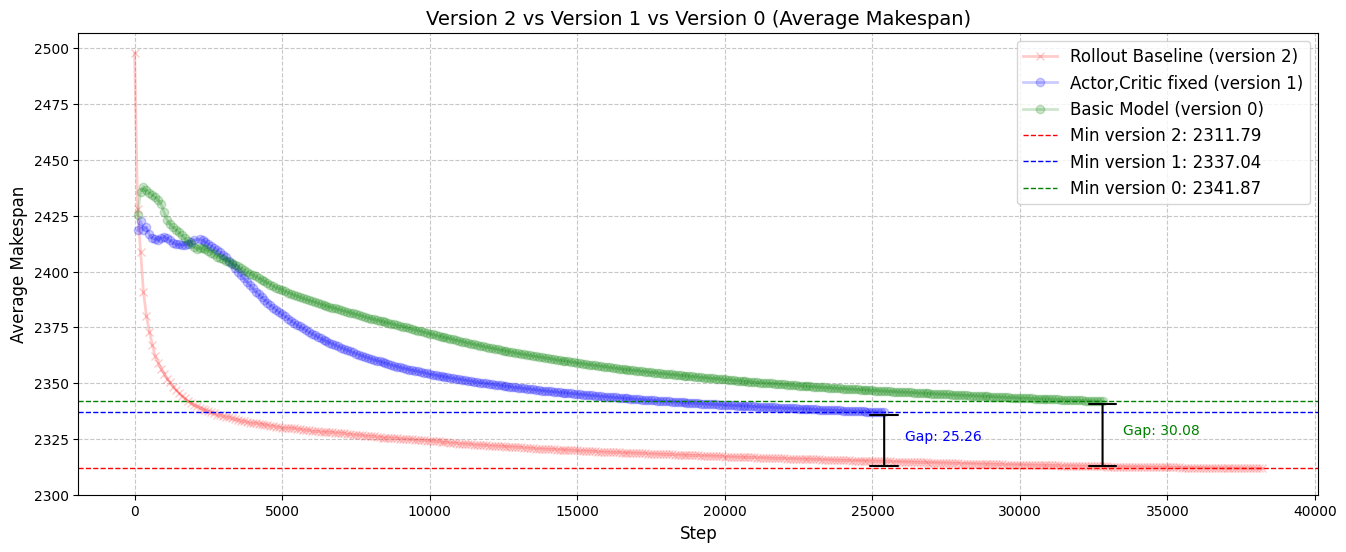

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file1_path = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\log\ppo_rollout\0115_19_10_train.csv"
file2_path = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\train.csv"
file3_path = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\log\ppo_rollout\0819_19_19_train.csv"

# CSV 파일 읽기
data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)
data3 = pd.read_csv(file3_path)

# step 100마다 데이터 필터링
data1 = data1[data1['step'] % 100 == 0]
data2 = data2[data2['step'] % 100 == 0]
data3 = data3[data3['step'] % 100 == 0]

# Rollout Baseline의 최소 avg_makespan을 기준으로 다른 데이터와 비교
rollout_min = data1['avg_makespan'].min()
rollout_min_step = data1[data1['avg_makespan'] == rollout_min]['step'].iloc[0]

basic_min = data2['average_makespan'].min()
basic_min_step = data2[data2['average_makespan'] == basic_min]['step'].iloc[0]

transformer_min = data3['average makespan'].min()
transformer_min_step = data3[data3['average makespan'] == transformer_min]['step'].iloc[0]

# 차이 계산
basic_gap = basic_min - rollout_min
transformer_gap = transformer_min - rollout_min

# 공통 스타일 설정
line_width = 2
marker_size = 6
transparency = 0.2  # 반투명도 설정

# (step, average makespan) 그래프
plt.figure(figsize=(16, 6))
plt.plot(data1['step'], data1['avg_makespan'], label="Rollout Baseline (version 2)", marker='x', markersize=marker_size, linewidth=line_width, color='red', alpha=transparency)
plt.plot(data2['step'], data2['average_makespan'], label="Actor,Critic fixed (version 1)", marker='o', markersize=marker_size, linewidth=line_width, color='blue', alpha=transparency)
plt.plot(data3['step'], data3['average makespan'], label="Basic Model (version 0)", marker='o', markersize=marker_size, linewidth=line_width, color='green', alpha=transparency)

# 최소값 지점 표시
plt.axhline(y=rollout_min, color='red', linestyle='--', linewidth=1, label=f"Min version 2: {rollout_min:.2f}")
plt.axhline(y=basic_min, color='blue', linestyle='--', linewidth=1, label=f"Min version 1: {basic_min:.2f}")
plt.axhline(y=transformer_min, color='green', linestyle='--', linewidth=1, label=f"Min version 0: {transformer_min:.2f}")

# 세로 화살표 추가
arrow_properties = dict(facecolor='black', arrowstyle='|-|', lw=1.5)

plt.annotate('', xy=(basic_min_step, basic_min), xytext=(basic_min_step, rollout_min),
             arrowprops=arrow_properties)
plt.annotate(f"Gap: {basic_gap:.2f}", xy=(basic_min_step + 2000, (basic_min + rollout_min) / 2),
             fontsize=10, color='blue', ha='center')

plt.annotate('', xy=(transformer_min_step, transformer_min), xytext=(transformer_min_step, rollout_min),
             arrowprops=arrow_properties)
plt.annotate(f"Gap: {transformer_gap:.2f}", xy=(transformer_min_step + 2000, (transformer_min + rollout_min) / 2),
             fontsize=10, color='green', ha='center')

# 제목 및 라벨
plt.title("Version 2 vs Version 1 vs Version 0 (Average Makespan)", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("Average Makespan", fontsize=12)

# y축 범위 설정
plt.ylim(2300, None)

# 범례 및 그리드 설정
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 그래프 표시
plt.show()


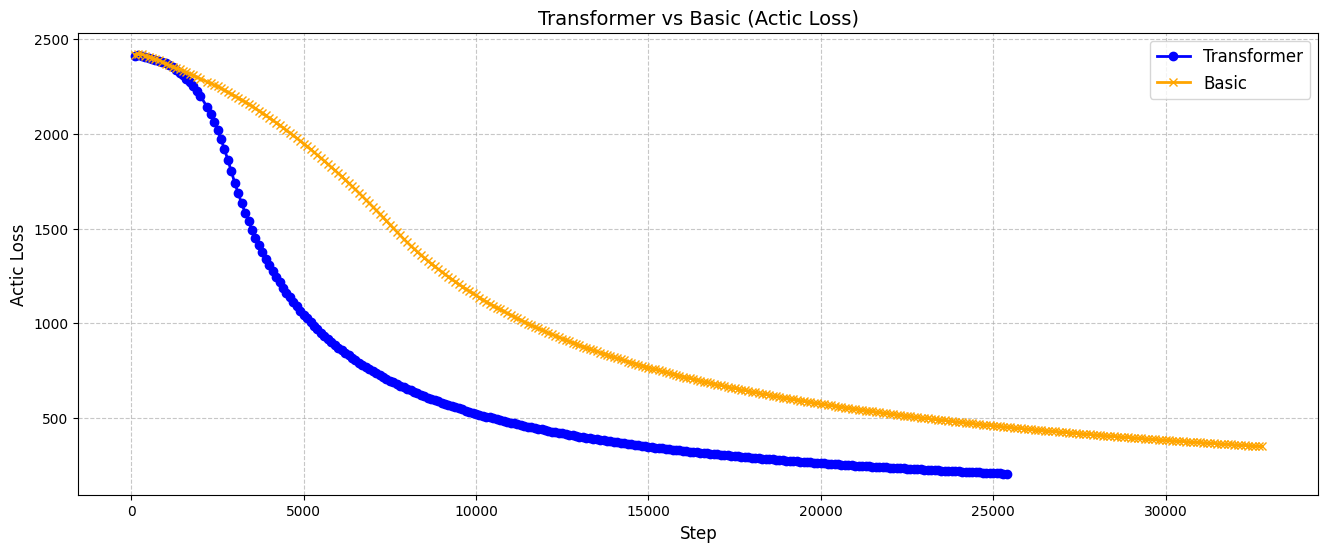

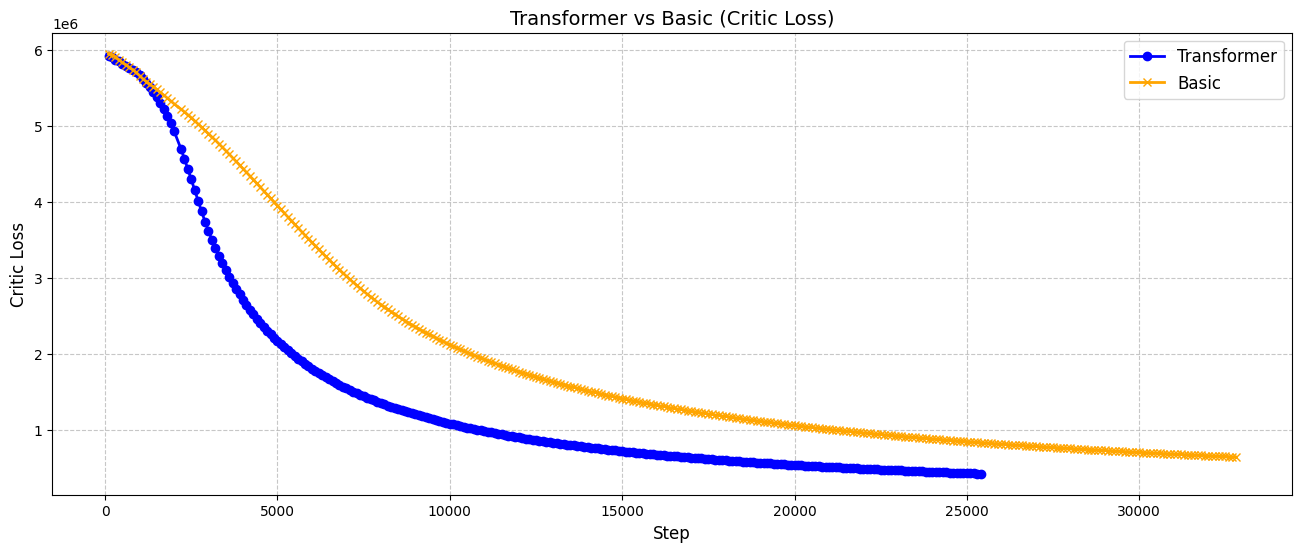

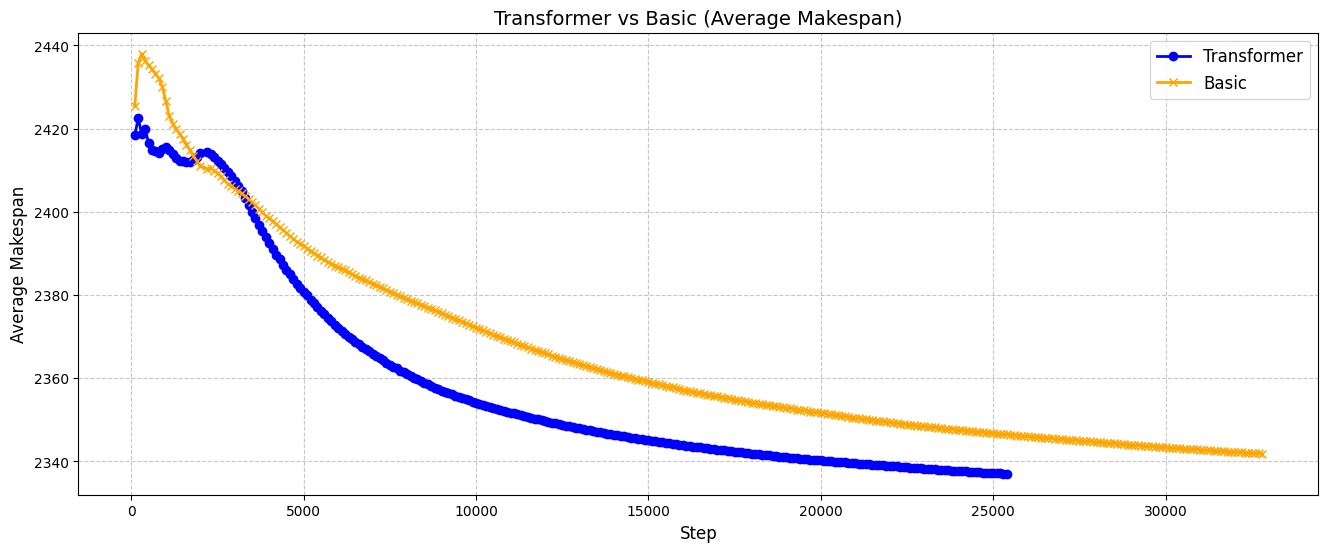

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file1_path = r"C:\Users\User\Desktop\연구실\과제\Contech\2차\fun\agent\result\log\ppo\train.csv"
file2_path = r"C:\Users\User\Desktop\연구실\과제\Contech\2차\fun\agent\result\log\ppo\0819_19_19_train.csv"


# CSV 파일 읽기
data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)

# 조건에 따라 데이터 필터링
filtered_data1 = data1[((data1['step'] >= 2) & (data1['step'] <= 2000)) | (data1['step'] >= 2200)]
filtered_data1 = filtered_data1[filtered_data1['step'] % 100 == 0]

filtered_data2 = data2[((data2['step'] >= 2) & (data2['step'] <= 2000)) | (data2['step'] >= 2200)]
filtered_data2 = filtered_data2[filtered_data2['step'] % 100 == 0]

# 공통 스타일 설정
line_width = 2
marker_size = 6

# (step, actic loss) 그래프
plt.figure(figsize=(16, 6))
plt.plot(filtered_data1['step'], filtered_data1['actic loss'], label="Transformer", marker='o', markersize=marker_size, linewidth=line_width, color='blue')
plt.plot(filtered_data2['step'], filtered_data2['actic loss'], label="Basic", marker='x', markersize=marker_size, linewidth=line_width, color='orange')
plt.title("Transformer vs Basic (Actic Loss)", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("Actic Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# (step, crictic loss) 그래프
plt.figure(figsize=(16, 6))
plt.plot(filtered_data1['step'], filtered_data1['crictic loss'], label="Transformer", marker='o', markersize=marker_size, linewidth=line_width, color='blue')
plt.plot(filtered_data2['step'], filtered_data2['crictic loss'], label="Basic", marker='x', markersize=marker_size, linewidth=line_width, color='orange')
plt.title("Transformer vs Basic (Critic Loss)", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("Critic Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# (step, average makespan) 그래프
plt.figure(figsize=(16, 6))
plt.plot(filtered_data1['step'], filtered_data1['average makespan'], label="Transformer", marker='o', markersize=marker_size, linewidth=line_width, color='blue')
plt.plot(filtered_data2['step'], filtered_data2['average makespan'], label="Basic", marker='x', markersize=marker_size, linewidth=line_width, color='orange')
plt.title("Transformer vs Basic (Average Makespan)", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("Average Makespan", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


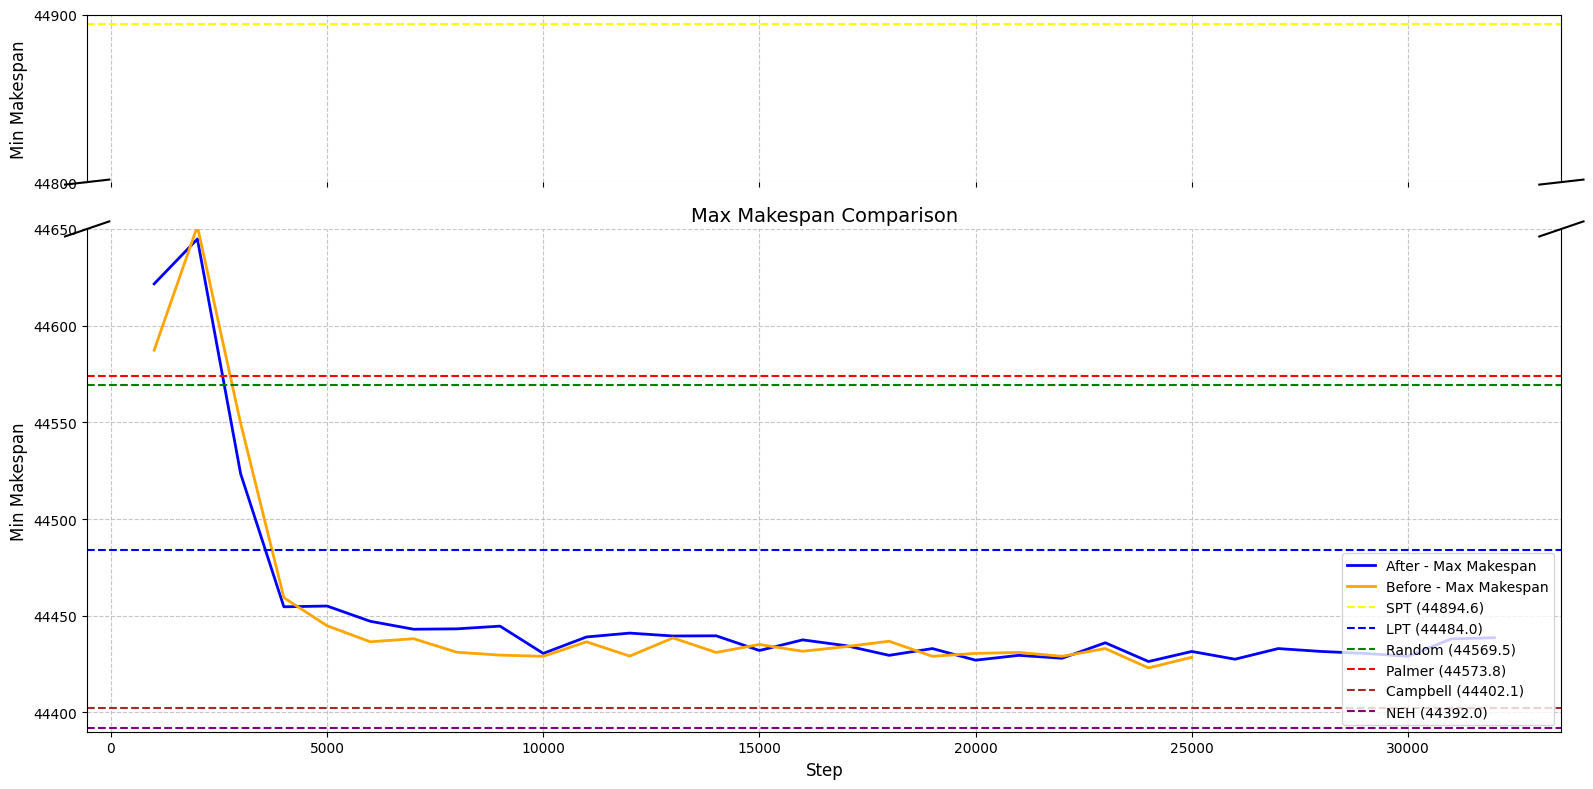

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file_after = r"C:\Users\User\Desktop\fun\agent\result\model\ppo\makespan_results.csv"
file_before = r"C:\Users\User\Desktop\fun\agent\result\model\ppo\makespan_results_after.csv"

# CSV 파일 읽기
data_after = pd.read_csv(file_after)
data_before = pd.read_csv(file_before)

# 추가 데이터
additional_data = {
    'method': ['SPT', 'LPT', 'Random', 'Palmer', 'Campbell', 'NEH'],
    'makespan': [44894.6, 44484.0, 44569.5, 44573.8, 44402.1, 44392.0],
    'color': ['yellow', 'blue', 'green', 'red', 'brown', 'purple']  # 각각 다른 색상
}
additional_df = pd.DataFrame(additional_data)

# 그래프 생성
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# 물결 위 그래프: 생략된 부분 표시
max_value = 44894  # 물결 위의 최댓값을 설정
ax1.set_ylim(44800, max_value)
ax1.set_yticks(range(44800, max_value + 100, 100))
ax1.plot(data_after['step'], data_after['max_makespan'], label="After - Max Makespan", color='blue', linewidth=2)
ax1.plot(data_before['step'], data_before['max_makespan'], label="Before - Max Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax1.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, label=row['method'])

# 물결표 표시
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)  # 상단 축 라벨 제거
ax2.tick_params(labeltop=False)  # 하단 축 라벨 제거
d = .015  # 물결 크기
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # 상단 물결
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # 하단 물결
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# 물결 아래 그래프: 주요 범위
ax2.set_ylim(44390, 44650)
ax2.plot(data_after['step'], data_after['max_makespan'], label="After - Max Makespan", color='blue', linewidth=2)
ax2.plot(data_before['step'], data_before['max_makespan'], label="Before - Max Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax2.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, 
                label=f"{row['method']} ({row['makespan']:.1f})")  # makespan 포함

# 범례 및 라벨 설정
plt.title("Max Makespan Comparison", fontsize=14)
ax2.legend(fontsize=10, loc="lower right")
ax2.set_xlabel("Step", fontsize=12)
ax1.set_ylabel("Min Makespan", fontsize=12)
ax2.set_ylabel("Min Makespan", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


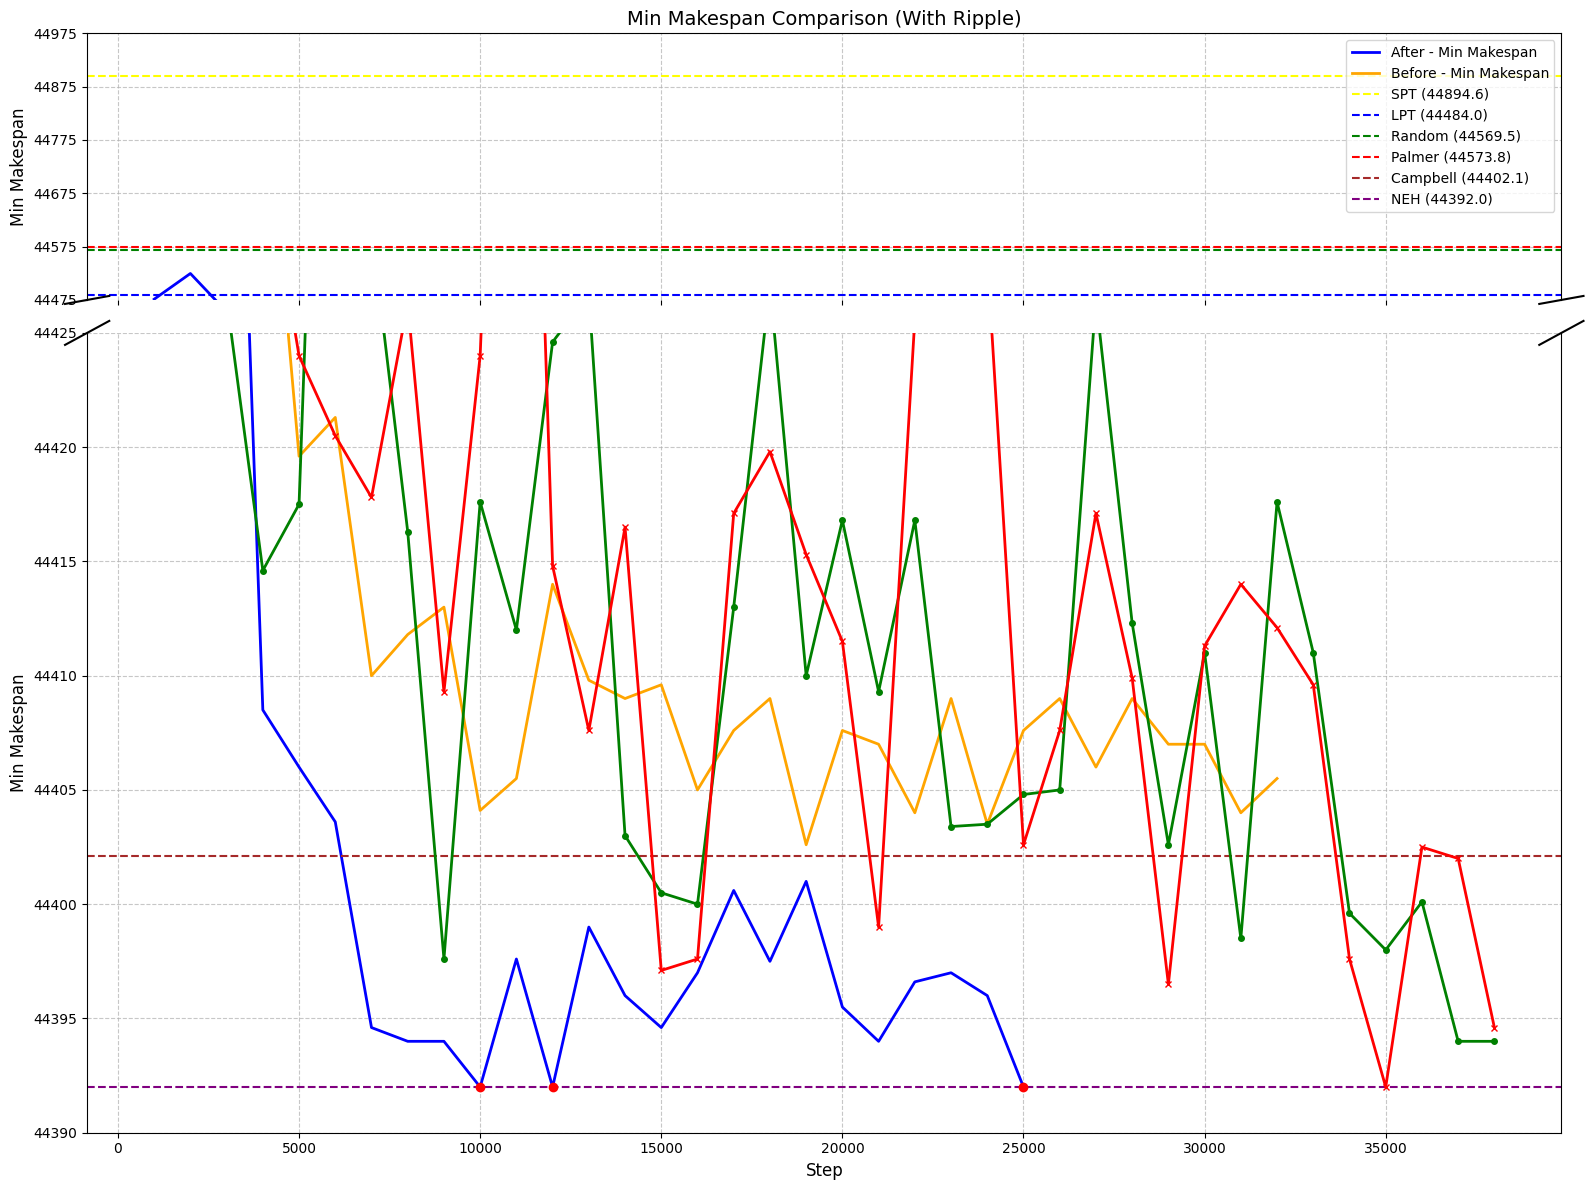

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file_after = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\makespan_results_after.csv"
file_before = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\makespan_results_before.csv"
file_test = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\0116_11_44_evaluation_results.csv"

# CSV 파일 읽기
data_after = pd.read_csv(file_after)
data_before = pd.read_csv(file_before)
data_test = pd.read_csv(file_test)

# 추가 데이터
additional_data = {
    'method': ['SPT', 'LPT', 'Random', 'Palmer', 'Campbell', 'NEH'],
    'makespan': [44894.6, 44484.0, 44569.5, 44573.8, 44402.1, 44392.0],
    'color': ['yellow', 'blue', 'green', 'red', 'brown', 'purple']  # 각각 다른 색상
}
additional_df = pd.DataFrame(additional_data)

# NEH 값 가져오기
neh_value = additional_df[additional_df['method'] == 'NEH']['makespan'].iloc[0]

# `model_type`에 따라 current와 baseline 분리
current_data = data_test[data_test['model_type'] == 'current']
baseline_data = data_test[data_test['model_type'] == 'baseline']

# 그래프 생성
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# 물결 위 그래프: 생략된 부분 표시
max_value = 44894  # 물결 위의 최댓값을 설정
ax1.set_ylim(44475, max_value)
ax1.set_yticks(range(44475, max_value + 100, 100))
ax1.plot(data_after['step'], data_after['min_makespan'], label="After - Min Makespan", color='blue', linewidth=2)
ax1.plot(data_before['step'], data_before['min_makespan'], label="Before - Min Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax1.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, 
                label=f"{row['method']} ({row['makespan']:.1f})")  # makespan 포함

# 물결표 표시
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)  # 상단 축 라벨 제거
ax2.tick_params(labeltop=False)  # 하단 축 라벨 제거
d = .015  # 물결 크기
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # 상단 물결
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # 하단 물결
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# 물결 아래 그래프: 주요 범위
ax2.set_ylim(44390, 44425)
ax2.plot(data_after['step'], data_after['min_makespan'], label="After - Min Makespan", color='blue', linewidth=2)
ax2.plot(data_before['step'], data_before['min_makespan'], label="Before - Min Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax2.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, 
                label=f"{row['method']} ({row['makespan']:.1f})")  # makespan 포함

# NEH와 같은 지점에 빨간 원 표시
for index, row in data_after.iterrows():
    if row['min_makespan'] == neh_value:
        ax2.plot(row['step'], row['min_makespan'], 'ro')
for index, row in data_before.iterrows():
    if row['min_makespan'] == neh_value:
        ax2.plot(row['step'], row['min_makespan'], 'ro', label="NEH Match")

# Current와 Baseline 데이터 추가
ax2.plot(current_data['step'], current_data['min'], label="Current - Min Makespan", color='green', linewidth=2, marker='o', markersize=4)
ax2.plot(baseline_data['step'], baseline_data['min'], label="Baseline - Min Makespan", color='red', linewidth=2, marker='x', markersize=4)

# 범례 및 설정
ax1.set_title("Min Makespan Comparison (With Ripple)", fontsize=14)
ax1.legend(fontsize=10, loc="upper right")
ax2.set_xlabel("Step", fontsize=12)
ax1.set_ylabel("Min Makespan", fontsize=12)
ax2.set_ylabel("Min Makespan", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


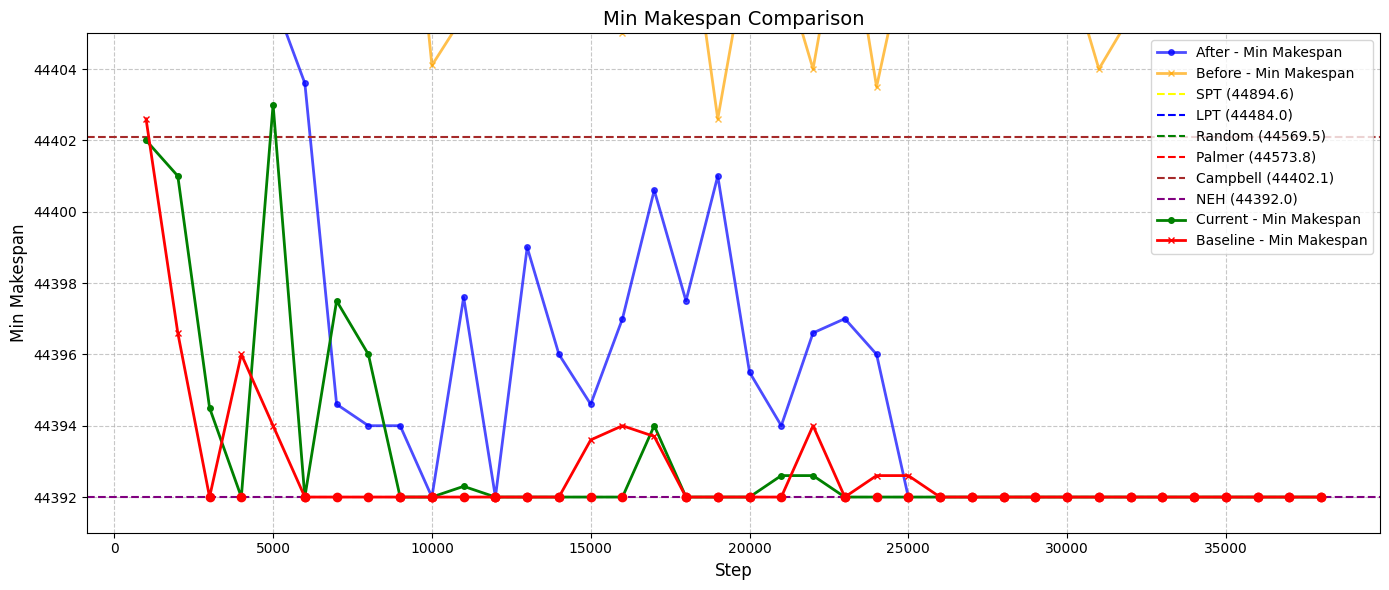

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file_after = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\makespan_results_after.csv"
file_before = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\makespan_results_before.csv"
file_test = r"C:\Users\User\Desktop\연구실\개인연구\PFSP_Reinforce\pbs_pointnetwork\agent\result\model\ppo_rollout\evaluation\0116_12_04_evaluation_results.csv"

# CSV 파일 읽기
data_after = pd.read_csv(file_after)
data_before = pd.read_csv(file_before)
data_test = pd.read_csv(file_test)

# 추가 데이터
additional_data = {
    'method': ['SPT', 'LPT', 'Random', 'Palmer', 'Campbell', 'NEH'],
    'makespan': [44894.6, 44484.0, 44569.5, 44573.8, 44402.1, 44392.0],
    'color': ['yellow', 'blue', 'green', 'red', 'brown', 'purple']  # 각각 다른 색상
}
additional_df = pd.DataFrame(additional_data)

# NEH 값 가져오기
neh_value = additional_df[additional_df['method'] == 'NEH']['makespan'].iloc[0]

# `model_type`에 따라 current와 baseline 분리
current_data = data_test[data_test['model_type'] == 'current']
baseline_data = data_test[data_test['model_type'] == 'baseline']

# 그래프 생성
fig, ax = plt.subplots(figsize=(14, 6))

# y축 범위 설정
# ax.set_ylim(44390, 44550)  # 최소값은 기존대로, 최대값을 44550으로 설정
ax.set_ylim(44391, 44405)  # 최소값은 기존대로, 최대값을 44550으로 설정

# After와 Before 데이터 추가
ax.plot(data_after['step'], data_after['min_makespan'], label="After - Min Makespan", color='blue', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax.plot(data_before['step'], data_before['min_makespan'], label="Before - Min Makespan", color='orange', linewidth=2, marker='x', markersize=4, alpha=0.7)

# 추가 데이터 추가
for i, row in additional_df.iterrows():
    ax.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, 
               label=f"{row['method']} ({row['makespan']:.1f})")

# Current와 Baseline 데이터 추가
ax.plot(current_data['step'], current_data['min'], label="Current - Min Makespan", color='green', linewidth=2, marker='o', markersize=4)
ax.plot(baseline_data['step'], baseline_data['min'], label="Baseline - Min Makespan", color='red', linewidth=2, marker='x', markersize=4)

# NEH와 같은 지점에 빨간 원 표시 (모든 그래프에 적용)
for index, row in data_after.iterrows():
    if abs(row['min_makespan'] - neh_value) < 0.1:  # 부동소수점 비교를 위한 허용 오차
        ax.plot(row['step'], row['min_makespan'], 'ro')
for index, row in data_before.iterrows():
    if abs(row['min_makespan'] - neh_value) < 0.1:
        ax.plot(row['step'], row['min_makespan'], 'ro')
for index, row in current_data.iterrows():
    if abs(row['min'] - neh_value) < 0.1:
        ax.plot(row['step'], row['min'], 'ro')
for index, row in baseline_data.iterrows():
    if abs(row['min'] - neh_value) < 0.1:
        ax.plot(row['step'], row['min'], 'ro')

# 설정
ax.set_title("Min Makespan Comparison", fontsize=14)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Min Makespan", fontsize=12)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로
file_after = r"C:\Users\User\Desktop\fun\agent\result\model\ppo\makespan_results.csv"
file_before = r"C:\Users\User\Desktop\fun\agent\result\model\ppo\makespan_results_after.csv"

# CSV 파일 읽기
data_after = pd.read_csv(file_after)
data_before = pd.read_csv(file_before)

# 추가 데이터
additional_data = {
    'method': ['SPT', 'LPT', 'Random', 'Palmer', 'Campbell', 'NEH'],
    'makespan': [44894.6, 44484.0, 44569.5, 44573.8, 44402.1, 44392.0],
    'color': ['yellow', 'blue', 'green', 'red', 'brown', 'purple']  # 각각 다른 색상
}
additional_df = pd.DataFrame(additional_data)

# 그래프 생성
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# 물결 위 그래프: 생략된 부분 표시
max_value = 44894  # 물결 위의 최댓값을 설정
ax1.set_ylim(44480, max_value)
ax1.set_yticks(range(44500, max_value + 100, 100))
ax1.plot(data_after['step'], data_after['avg_makespan'], label="After - Avg Makespan", color='blue', linewidth=2)
ax1.plot(data_before['step'], data_before['avg_makespan'], label="Before - Avg Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax1.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, label=row['method'])

# 물결표 표시
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)  # 상단 축 라벨 제거
ax2.tick_params(labeltop=False)  # 하단 축 라벨 제거
d = .015  # 물결 크기
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # 상단 물결
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # 하단 물결
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# 물결 아래 그래프: 주요 범위
ax2.set_ylim(44390, 44460)
ax2.plot(data_after['step'], data_after['avg_makespan'], label="After - Avg Makespan", color='blue', linewidth=2)
ax2.plot(data_before['step'], data_before['avg_makespan'], label="Before - Avg Makespan", color='orange', linewidth=2)
for i, row in additional_df.iterrows():
    ax2.axhline(y=row['makespan'], color=row['color'], linestyle='--', linewidth=1.5, 
                label=f"{row['method']} ({row['makespan']:.1f})")  # makespan 포함

# 범례 및 라벨 설정
plt.title("Avg Makespan Comparison", fontsize=14)
ax2.legend(fontsize=10, loc="lower right")
ax2.set_xlabel("Step", fontsize=12)
ax1.set_ylabel("Min Makespan", fontsize=12)
ax2.set_ylabel("Min Makespan", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\fun\\agent\\result\\model\\ppo\\makespan_results.csv'